## Tiền xử lý dữ liệu
Dữ liệu đầu vào gồm các features, đầu tiên cần hiểu rõ các cột này mang ý nghĩa gì:  
-HeartDisease : Có bệnh tim hay không ( cột cần dự đoán)  
**Nhóm chỉ số số học :**  
-BMI : Chỉ số khối cơ thể  
-PhysicalHealth:Số ngày sức khỏe thể chất không tốt trong 30 ngày gần nhất  
-MentalHealth:Số ngày sức khỏe tinh thần không tốt trong 30 ngày gần nhất  
-SleepTime:Số giờ ngủ trung bình mỗi ngày  
**Nhóm biến Yes/No :**  
-Smoking : Có hút thuốc không  
-AlcoholDrinking:Có uống rượu nhiều không  
-Stroke: Có từng bị đột quỵ không  
-DiffWalking: Có khó khăn khi đi bộ không  
-PhysicalActivity: Có hoạt động thể chất không  
-Asthma: Có hen suyễn không  
-KidneyDisease:Có bệnh thận không  
-SkinCancer:Có ung thư da không  
**Nhóm biến phân loại nhiều giá trị :**  
-Sex:Giới tính  
-AgeCategory:Nhóm tuổi  
-Race: Chủng tộc  
-Diabetic: Tình trạng tiểu đường  
-GenHealth:	Tự đánh giá sức khỏe tổng quát  



## Đọc thông tin và mô tả dữ liệu

In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. Đọc dữ liệu
df = pd.read_csv("heart_2020_cleaned.csv")
print(f"Kích thước ban đầu: {df.shape}")


# Phân loại cột
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']


Kích thước ban đầu: (319795, 18)


In [275]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  str    
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  str    
 3   AlcoholDrinking   319795 non-null  str    
 4   Stroke            319795 non-null  str    
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  str    
 8   Sex               319795 non-null  str    
 9   AgeCategory       319795 non-null  str    
 10  Race              319795 non-null  str    
 11  Diabetic          319795 non-null  str    
 12  PhysicalActivity  319795 non-null  str    
 13  GenHealth         319795 non-null  str    
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  str    
 16  KidneyDisease     319795 non-nu

In [276]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


Kiểm tra dữ liệu thiếu 

Dữ liệu thiếu là các ô bị rỗng hoặc có giá trị NaN. Nếu dữ liệu có nhiều giá trị thiếu, ta cần xử lý bằng cách điền trung bình, trung vị, mode hoặc xóa dòng bị thiếu.

In [277]:
#3 : Kiểm tra số lượng giá trị thiếu ở từng cột
missing_values = df.isnull().sum()

print("Số giá trị thiếu theo từng cột:")
print(missing_values)

Số giá trị thiếu theo từng cột:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64


Kiểm tra và xử lý dữ liệu trùng lặp  
Dữ liệu trùng lặp là các dòng có thông tin giống hệt nhau. Nếu giữ lại các dòng trùng lặp, mô hình có thể học lệch vì một số mẫu xuất hiện nhiều lần.

In [278]:
# Xóa dòng trùng lặp
df = df.drop_duplicates()

# Đánh lại index
df = df.reset_index(drop=True)

print("Kích thước sau khi xóa trùng:", df.shape)

Kích thước sau khi xóa trùng: (301717, 18)


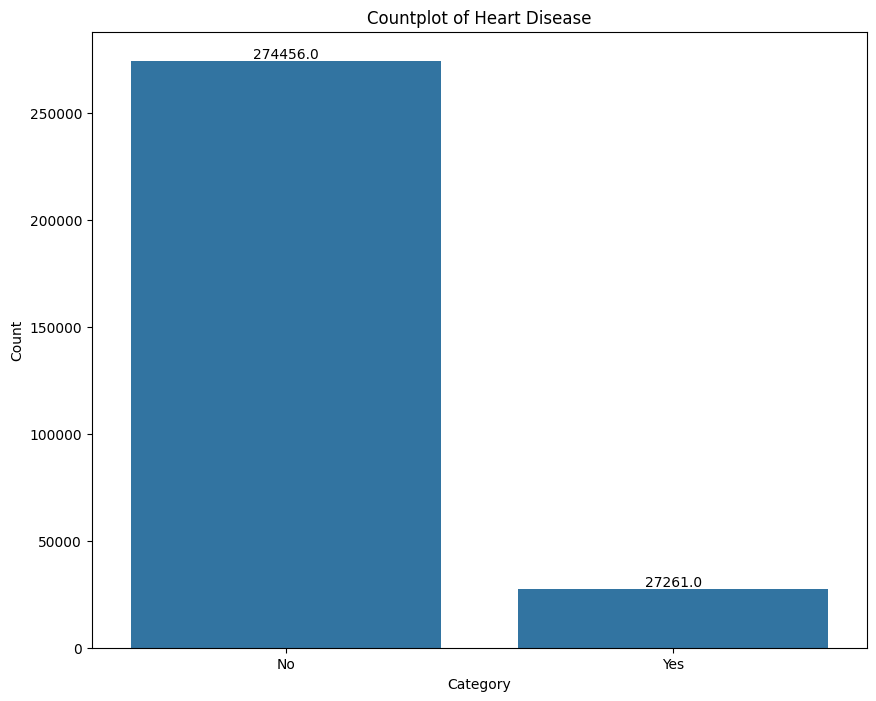

In [279]:
# Distribution of Target Variable
plt.figure(figsize = (10, 8))
ax = sns.countplot(x = 'HeartDisease', data = df)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')
plt.title("Countplot of Heart Disease")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [280]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,301717.000000,301717.000000,301717.000000,301717.000000
mean,28.441970,3.572298,4.121475,7.084559
std,6.468134,8.140656,8.128288,1.467122
min,12.020000,0.000000,0.000000,1.000000
25%,24.030000,0.000000,0.000000,6.000000
50%,27.410000,0.000000,0.000000,7.000000
75%,31.650000,2.000000,4.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000


## Trực quan hóa các biến số

--- TRỰC QUAN HÓA DỮ LIỆU GỐC ---


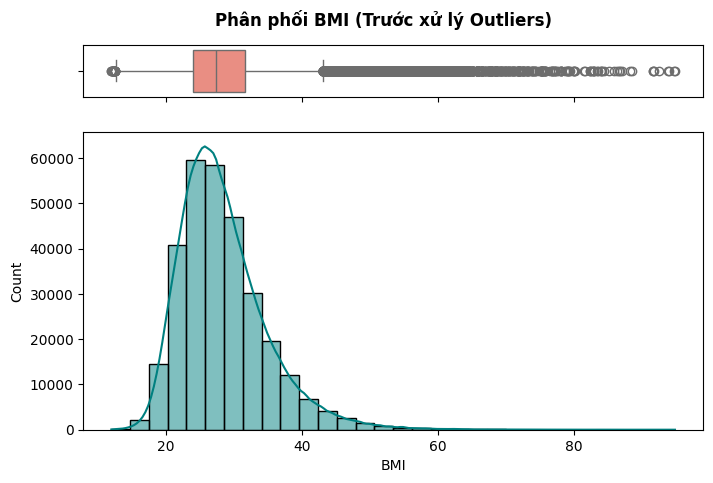

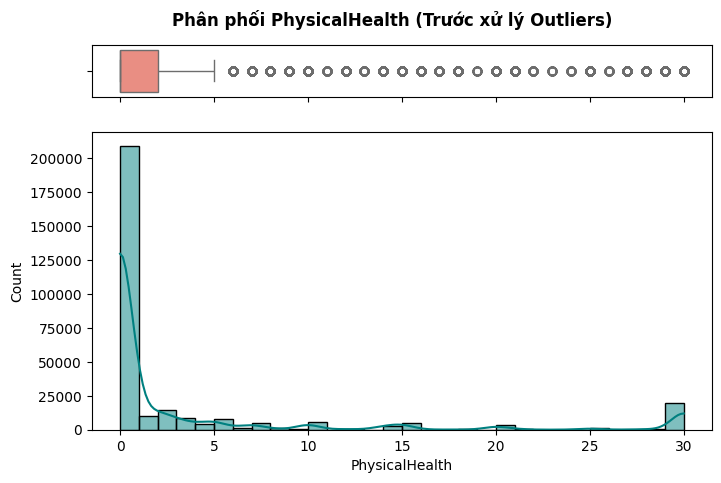

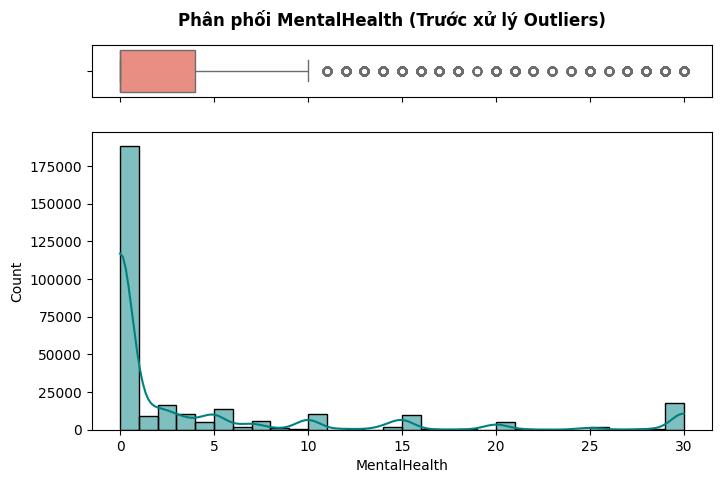

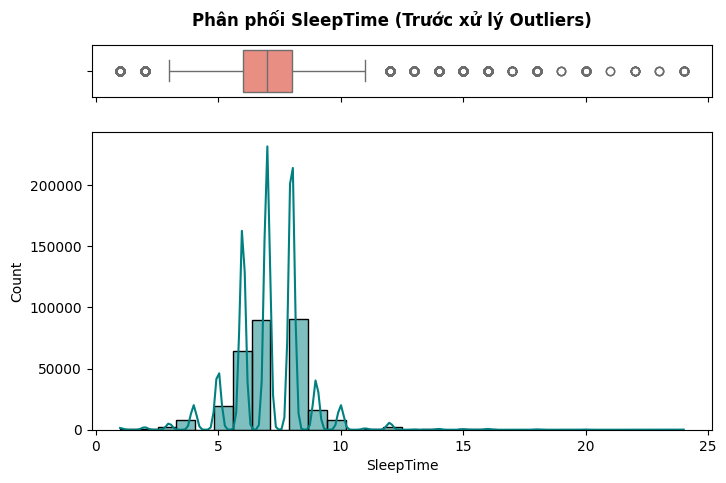

In [281]:
# Hàm vẽ biểu đồ thống nhất
def plot_unified(data, columns, title_suffix=""):
    for col in columns:
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(8, 5))
        
        sns.boxplot(x=data[col], ax=ax_box, color='salmon')
        ax_box.set(xlabel='')
        
        sns.histplot(data[col], ax=ax_hist, kde=True, color='teal', bins=30)
        
        plt.suptitle(f'Phân phối {col} {title_suffix}', y=0.95, fontweight='bold')
        plt.show()

# Vẽ cho dữ liệu gốc
print("--- TRỰC QUAN HÓA DỮ LIỆU GỐC ---")
plot_unified(df, num_cols, "(Trước xử lý Outliers)")

## Xử lý Outliers

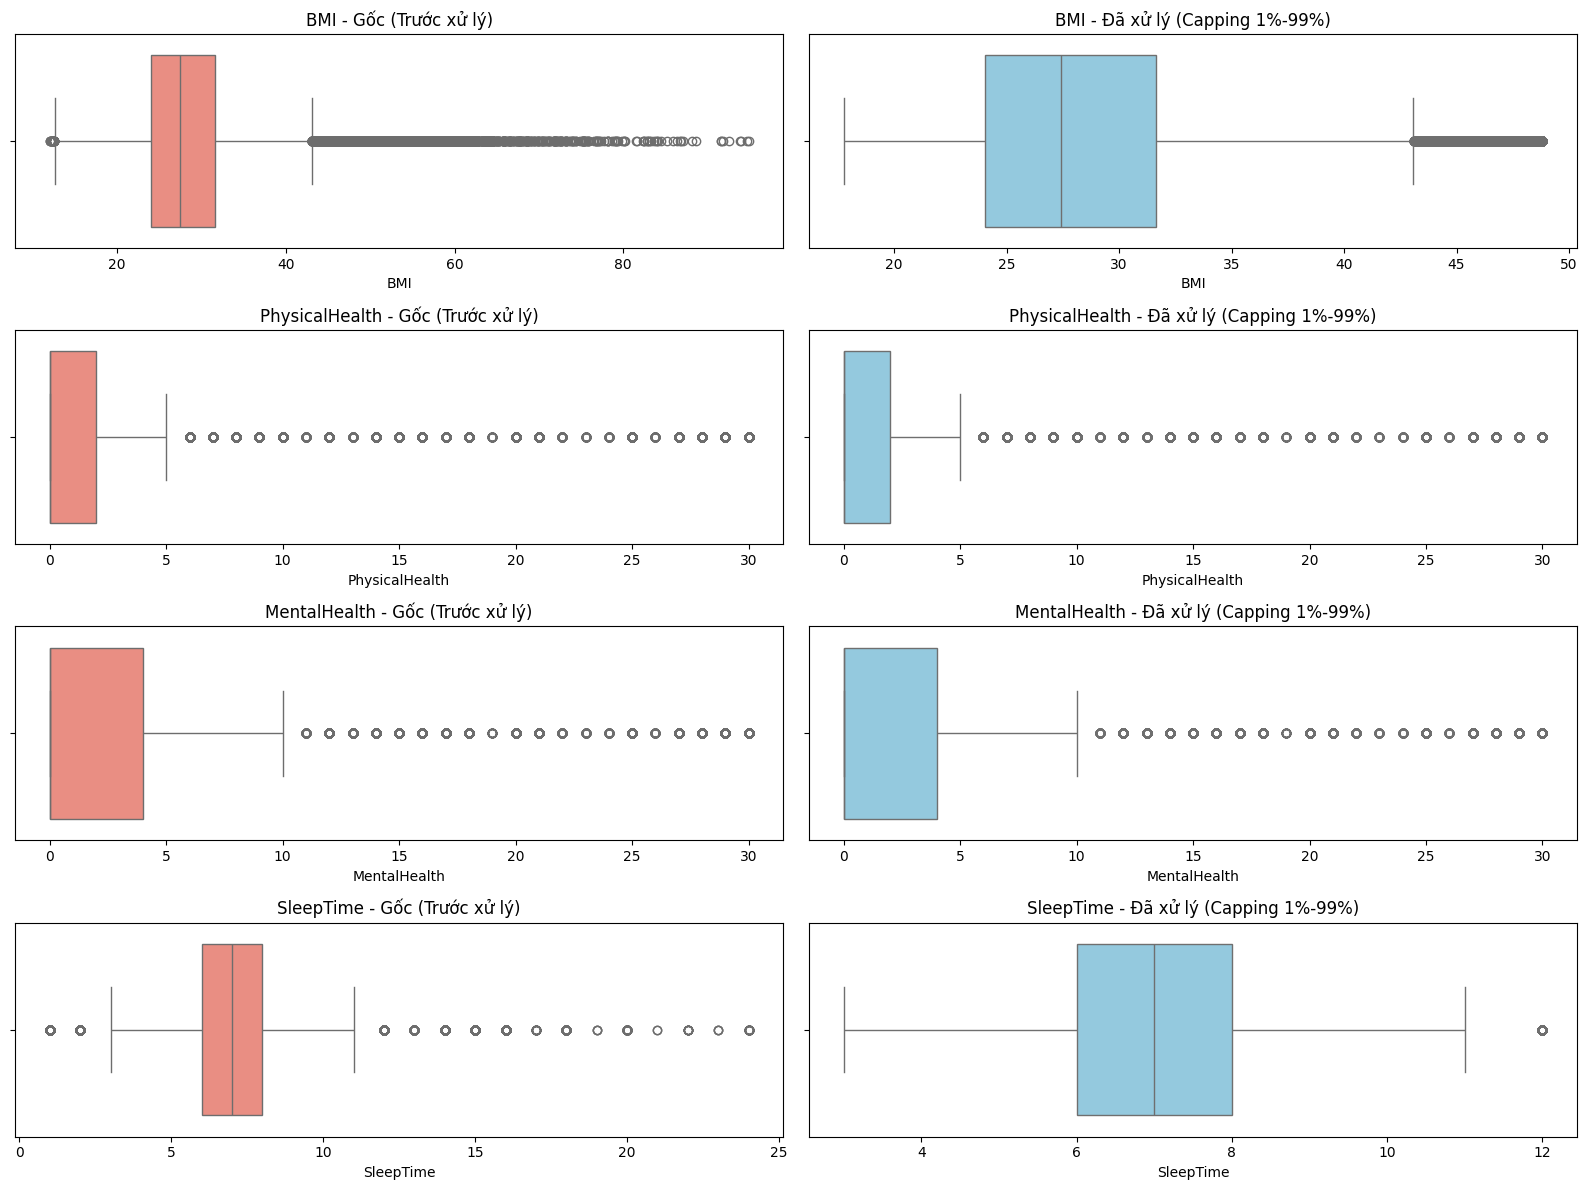

In [282]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chọn các cột số cần xử lý
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

# 2. Thực hiện Capping (Winsorization)
df_cleaned = df.copy()
for col in num_cols:
    lower_limit = df[col].quantile(0.01) # Phân vị 1%
    upper_limit = df[col].quantile(0.99) # Phân vị 99%
    df_cleaned[col] = df_cleaned[col].clip(lower_limit, upper_limit)

# 3. Vẽ đồ thị so sánh (Ví dụ cho toàn bộ các cột)
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols):
    # Trước xử lý
    plt.subplot(4,2, 2*i + 1)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'{col} - Gốc (Trước xử lý)')
    
    # Sau xử lý
    plt.subplot(4, 2, 2*i + 2)
    sns.boxplot(x=df_cleaned[col], color='skyblue')
    plt.title(f'{col} - Đã xử lý (Capping 1%-99%)')

plt.tight_layout()
plt.show()

## Trực quan hóa các biến phân loại

C:\Users\Hoang Dung\AppData\Local\Temp\ipykernel_20100\3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\Hoang Dung\AppData\Local\Temp\ipykernel_20100\3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\Hoang Dung\AppData\Local\Temp\ipykernel_20100\3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\Hoang Dung\AppData\Local\Temp\i

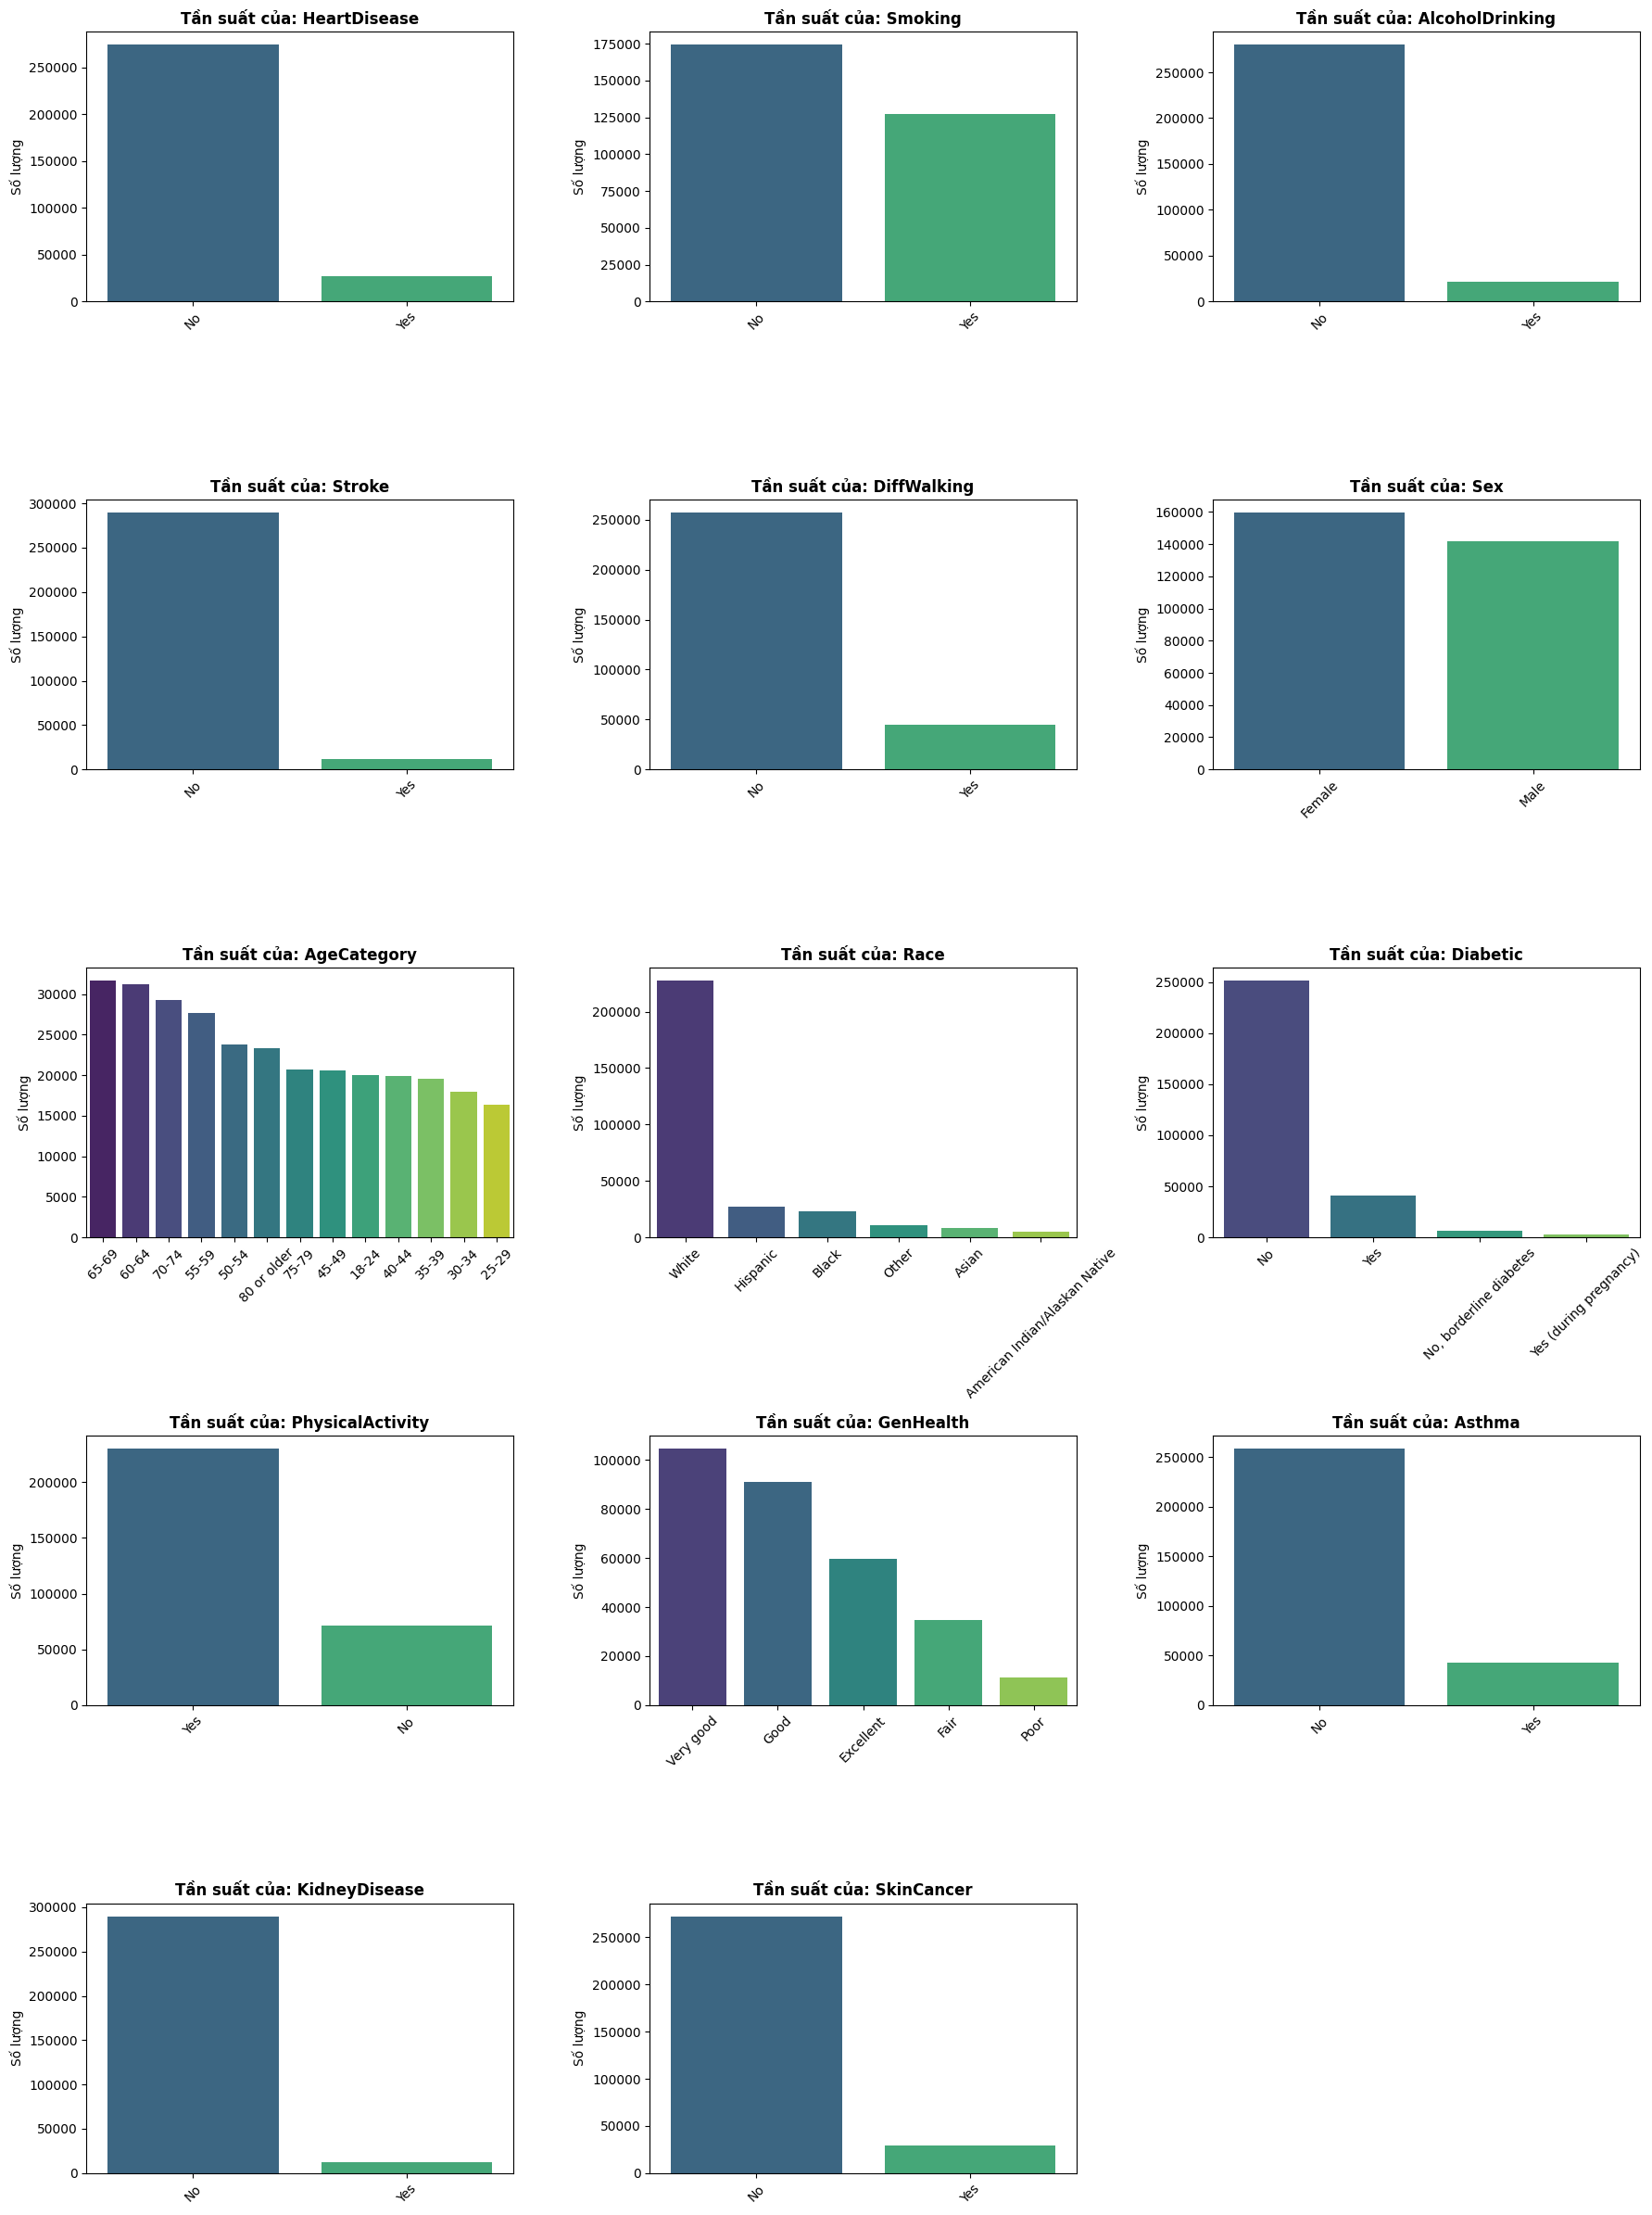

In [283]:
# Lấy danh sách các biến phân loại (loại trừ 4 biến số đã vẽ)
cat_cols = [col for col in df.columns if col not in num_cols]

# Tạo khung hình lớn chứa nhiều biểu đồ nhỏ (Grid)
plt.figure(figsize=(18, 24))

for i, col in enumerate(cat_cols):
    plt.subplot(5, 3, i+1) # Vẽ lưới 5 hàng 3 cột
    
    # Sắp xếp các cột theo số lượng từ cao xuống thấp để biểu đồ gọn gàng
    order = df[col].value_counts().index
    
    # Vẽ biểu đồ tần suất (Countplot) với màu sắc đồng bộ
    sns.countplot(data=df, x=col, order=order, palette='viridis')
    
    plt.title(f'Tần suất của: {col}', fontweight='bold')
    plt.xticks(rotation=45) # Xoay nghiêng chữ ở trục X để không bị đè lên nhau
    plt.xlabel('')
    plt.ylabel('Số lượng')

# Tự động căn chỉnh khoảng cách giữa các đồ thị
plt.tight_layout()
plt.show()

Kiểm tra phân bố nhãn HeartDisease

In [284]:
# Kiểm tra số lượng từng nhãn
label_count = df["HeartDisease"].value_counts()

# Kiểm tra tỷ lệ từng nhãn
label_ratio = df["HeartDisease"].value_counts(normalize=True)

print("Số lượng từng lớp:")
print(label_count)

print("Tỷ lệ từng lớp:")
print(label_ratio)

Số lượng từng lớp:
HeartDisease
No     274456
Yes     27261
Name: count, dtype: int64
Tỷ lệ từng lớp:
HeartDisease
No     0.909647
Yes    0.090353
Name: proportion, dtype: float64


Dữ liệu bị mất cân bằng nhãn khá rõ. Lớp No, tức không mắc bệnh tim, chiếm khoảng 91%. Lớp Yes, tức mắc bệnh tim, chỉ chiếm khoảng 9%.

Điều này có thể làm mô hình thiên về lớp chiếm đa số. Ví dụ, nếu mô hình luôn dự đoán mọi người là không mắc bệnh tim, mô hình vẫn có accuracy khoảng 91%, nhưng thực tế mô hình đó gần như vô dụng vì không phát hiện được người mắc bệnh tim.

Ví vậy khi đánh giá cần quan tâm thêm các chỉ số như :  
Precision  
Recall  
F1-score  
Confusion matrix  

Chuyển đổi dữ liệu về dạng phù hợp

Mã hóa các biến Yes/No

Các cột dạng Yes/No gồm :  
HeartDisease  
Smoking  
AlcoholDrinking  
Stroke  
DiffWalking  
PhysicalActivity  
Asthma  
KidneyDisease  
SkinCancer  

In [285]:
binary_cols = [
    "HeartDisease",
    "Smoking",
    "AlcoholDrinking",
    "Stroke",
    "DiffWalking",
    "PhysicalActivity",
    "Asthma",
    "KidneyDisease",
    "SkinCancer"
]

for col in binary_cols:
    df[col] = df[col].map({
        "No": 0,
        "Yes": 1
    })

In [286]:
# Xóa khoảng trắng thừa và chuẩn hóa chuỗi trước khi mã hóa
df['Sex'] = df['Sex'].str.strip().map({
    "Female": 0,
    "Male": 1
})

# Kiểm tra lại xem còn giá trị NaN không
print("Số giá trị NaN trong cột Sex:", df['Sex'].isnull().sum())

Số giá trị NaN trong cột Sex: 0


Mã hóa biến AgeCategory

In [287]:
age_order = [
    "18-24", "25-29", "30-34", "35-39", "40-44",
    "45-49", "50-54", "55-59", "60-64", "65-69",
    "70-74", "75-79", "80 or older"
]

age_map = {age: idx for idx, age in enumerate(age_order)}

df["AgeCategory"] = df["AgeCategory"].map(age_map)

Mã hóa biến GenHealth

In [288]:
gen_health_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very good": 4,
    "Excellent": 5
}

df["GenHealth"] = df["GenHealth"].map(gen_health_map)

One-hot encoding cho Race và Diabetic

In [289]:
df = pd.get_dummies(
    df,
    columns=["Race", "Diabetic"],
    drop_first=False,
    dtype=int
)

Đưa HeartDisease về cột đầu tiên

In [290]:
target = df.pop("HeartDisease")
df.insert(0, "HeartDisease", target)

print("Kích thước dữ liệu sau mã hóa:", df.shape)
display(df.head(15))

Kích thước dữ liệu sau mã hóa: (301717, 26)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0,16.60,1,0,0,3.0,30.0,0,0,7,...,0,0,0,0,0,1,0,0,1,0
1,0,20.34,0,0,1,0.0,0.0,0,0,12,...,0,0,0,0,0,1,1,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,...,0,0,0,0,0,1,0,0,1,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,...,0,0,0,0,0,1,1,0,0,0
4,0,23.71,0,0,0,28.0,0.0,1,0,4,...,0,0,0,0,0,1,1,0,0,0
5,1,28.87,1,0,0,6.0,0.0,1,0,11,...,0,0,1,0,0,0,1,0,0,0
6,0,21.63,0,0,0,15.0,0.0,0,0,10,...,0,0,0,0,0,1,1,0,0,0
7,0,31.64,1,0,0,5.0,0.0,1,0,12,...,0,0,0,0,0,1,0,0,1,0
8,0,26.45,0,0,0,0.0,0.0,0,0,12,...,0,0,0,0,0,1,0,1,0,0
9,0,40.69,0,0,0,0.0,0.0,1,1,9,...,0,0,0,0,0,1,1,0,0,0


## Biểu đồ tương quan(Heatmap)

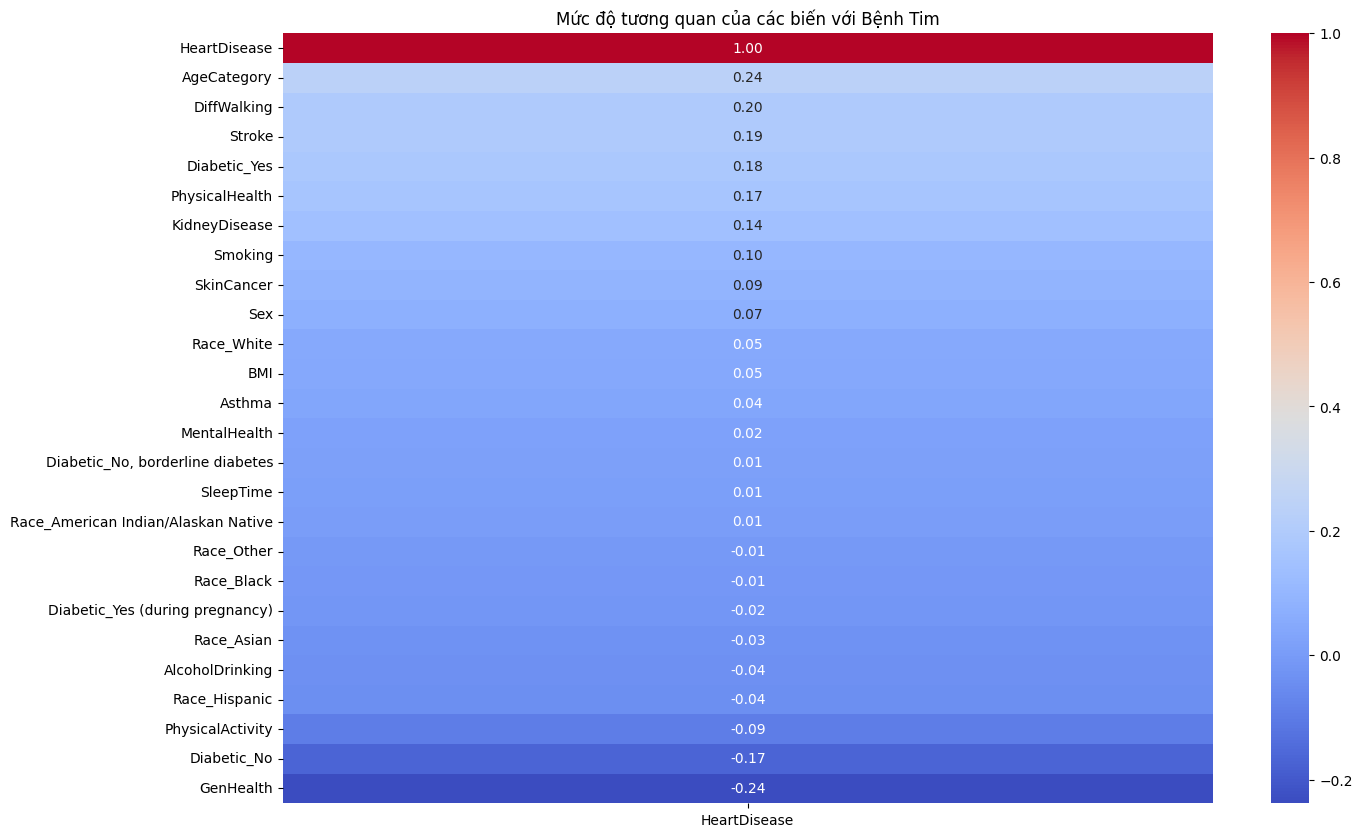

In [291]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán ma trận tương quan
# Nếu không có `df_cleaned`, dùng `df` sau tiền xử lý
corr_matrix = df.corr()

# Vẽ Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix[['HeartDisease']].sort_values(by='HeartDisease', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mức độ tương quan của các biến với Bệnh Tim')
plt.show()

## Biểu đồ tương quan giữa tất cả các biến

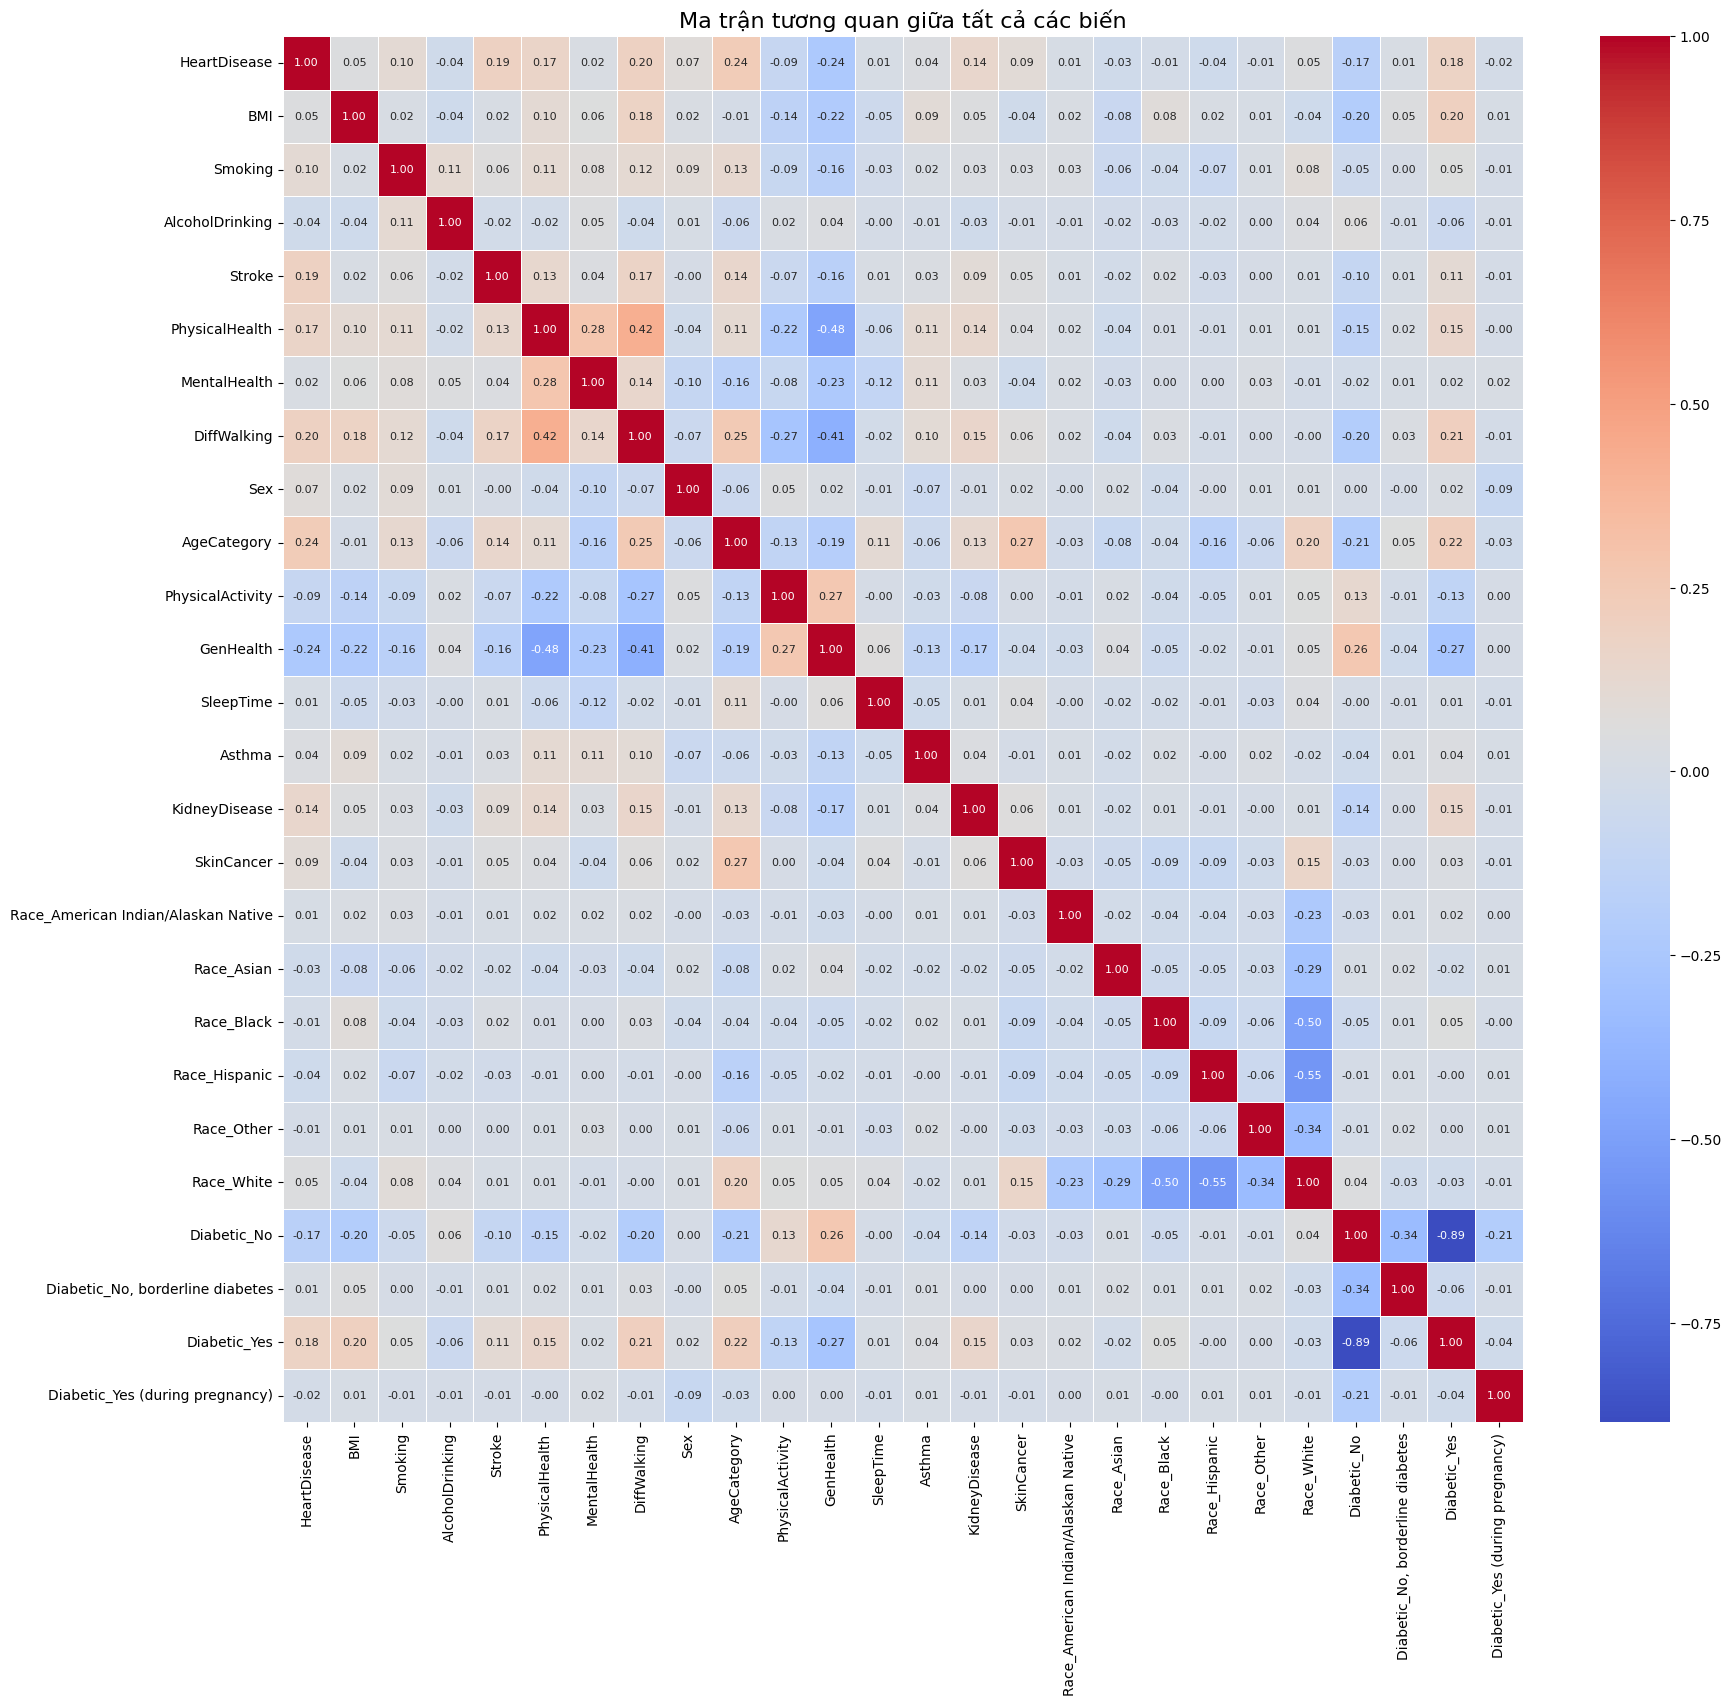

In [292]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán ma trận tương quan đầy đủ
full_corr_matrix = df.corr()

# Vẽ Heatmap cho toàn bộ ma trận tương quan
plt.figure(figsize=(20, 18)) # Kích thước lớn hơn để hiển thị nhiều biến
sns.heatmap(full_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
plt.title('Ma trận tương quan giữa tất cả các biến', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Chia dữ liệu train/test

In [293]:
from sklearn.model_selection import train_test_split

# 1. Tách biến độc lập (X) và biến mục tiêu (y)
# Dùng df sau khi đã xử lý và mã hóa để tránh còn giá trị chuỗi
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print(f"Tổng số bản ghi ban đầu: {len(df)}\n")
print("-" * 50)

# ==========================================
# TRƯỜNG HỢP 1: TỈ LỆ 4:1 (80% Train - 20% Test)
# Đây là tỉ lệ "Vàng" phổ biến nhất.
# ==========================================
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("1. KẾT QUẢ CHIA TỈ LỆ 4:1 (80/20)")
print(f"   - Tập Train (80%): {X_train_80.shape[0]} dòng")
print(f"   - Tập Test  (20%): {X_test_20.shape[0]} dòng")
print("-" * 50)


# ==========================================
# TRƯỜNG HỢP 2: TỈ LỆ 7:3 (70% Train - 30% Test)
# Dùng khi bộ dữ liệu cực lớn, cần tập Test lớn hơn để đánh giá chắc chắn.
# ==========================================
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("2. KẾT QUẢ CHIA TỈ LỆ 7:3 (70/30)")
print(f"   - Tập Train (70%): {X_train_70.shape[0]} dòng")
print(f"   - Tập Test  (30%): {X_test_30.shape[0]} dòng")
print("-" * 50)


# ==========================================
# TRƯỜNG HỢP 3: TỈ LỆ 6:4 (60% Train - 40% Test)
# Dùng để kiểm tra xem mô hình có bị Overfitting nặng không khi thiếu dữ liệu học.
# ==========================================
X_train_60, X_test_40, y_train_60, y_test_40 = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
print("3. KẾT QUẢ CHIA TỈ LỆ 6:4 (60/40)")
print(f"   - Tập Train (60%): {X_train_60.shape[0]} dòng")
print(f"   - Tập Test  (40%): {X_test_40.shape[0]} dòng")
print("-" * 50)

Tổng số bản ghi ban đầu: 301717

--------------------------------------------------
1. KẾT QUẢ CHIA TỈ LỆ 4:1 (80/20)
   - Tập Train (80%): 241373 dòng
   - Tập Test  (20%): 60344 dòng
--------------------------------------------------
2. KẾT QUẢ CHIA TỈ LỆ 7:3 (70/30)
   - Tập Train (70%): 211201 dòng
   - Tập Test  (30%): 90516 dòng
--------------------------------------------------
3. KẾT QUẢ CHIA TỈ LỆ 6:4 (60/40)
   - Tập Train (60%): 181030 dòng
   - Tập Test  (40%): 120687 dòng
--------------------------------------------------


tham số stratify=y đảm bảo người mắc bệnh có tỉ lệ đồng đều ở cả 2 tập


## Chuẩn hóa các dữ liệu dạng số 

In [294]:
from sklearn.preprocessing import StandardScaler

def scale_data(X_train, X_test):
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)  # fit + transform train
    X_test_scaled = scaler.transform(X_test)        # chỉ transform test
    
    return X_train_scaled, X_test_scaled, scaler

# 80/20
X_train_80_s, X_test_20_s, scaler_80 = scale_data(X_train_80, X_test_20)

# 70/30
X_train_70_s, X_test_30_s, scaler_70 = scale_data(X_train_70, X_test_30)

# 60/40
X_train_60_s, X_test_40_s, scaler_60 = scale_data(X_train_60, X_test_40)

In [295]:
import pandas as pd

def show_scaled_data(X_train, X_test, X_train_scaled, X_test_scaled, name):
    # Lấy tên cột
    cols = X_train.columns
    
    # Convert về DataFrame
    train_df = pd.DataFrame(X_train_scaled, columns=cols)
    test_df  = pd.DataFrame(X_test_scaled, columns=cols)
    
    print(f"\n===== {name} =====")
    
    print("\nTrain sau chuẩn hóa:")
    print(display(train_df.head()))
    
    print("\nTest sau chuẩn hóa:")
    print(display(test_df.head()))
    
    print("\nThống kê Train:")
    print(train_df.describe().loc[['mean','std']])

In [296]:
# 80/20
show_scaled_data(
    X_train_80, X_test_20,
    X_train_80_s, X_test_20_s,
    "80/20"
)

# 70/30
show_scaled_data(
    X_train_70, X_test_30,
    X_train_70_s, X_test_30_s,
    "70/30"
)

# 60/40
show_scaled_data(
    X_train_60, X_test_40,
    X_train_60_s, X_test_40_s,
    "60/40"
)


===== 80/20 =====

Train sau chuẩn hóa:


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0.474667,-0.853203,-0.277247,-0.204554,-0.439058,-0.137842,-0.415844,-0.944501,-0.142151,0.555609,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,0.44439,-0.151561,-0.393166,-0.093006
1,-1.067100,-0.853203,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,-0.944501,0.695189,0.555609,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,0.44439,-0.151561,-0.393166,-0.093006
2,0.539616,1.172053,-0.277247,-0.204554,1.277402,-0.506526,-0.415844,1.058760,-0.142151,-1.799826,...,-0.132200,-0.165116,3.501334,-0.314823,-0.192815,-1.754719,0.44439,-0.151561,-0.393166,-0.093006
3,-0.600086,-0.853203,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,-0.944501,-1.816830,-1.799826,...,-0.132200,-0.165116,-0.285605,3.176390,-0.192815,-1.754719,0.44439,-0.151561,-0.393166,-0.093006
4,1.359212,1.172053,-0.277247,-0.204554,0.051359,-0.506526,-0.415844,1.058760,0.416075,0.555609,...,7.564277,-0.165116,-0.285605,-0.314823,-0.192815,-1.754719,0.44439,-0.151561,-0.393166,-0.093006


None

Test sau chuẩn hóa:


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,-0.399053,1.172053,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,-0.944501,1.253415,0.555609,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,0.444390,-0.151561,-0.393166,-0.093006
1,-0.204205,-0.853203,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,1.058760,-1.258604,-1.799826,...,-0.132200,-0.165116,-0.285605,3.176390,-0.192815,-1.754719,0.444390,-0.151561,-0.393166,-0.093006
2,-0.562972,1.172053,-0.277247,-0.204554,-0.439058,-0.260737,-0.415844,-0.944501,-1.816830,0.555609,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,0.444390,-0.151561,-0.393166,-0.093006
3,-0.204205,1.172053,-0.277247,-0.204554,-0.439058,-0.506526,-0.415844,1.058760,-1.816830,0.555609,...,7.564277,-0.165116,-0.285605,-0.314823,-0.192815,-1.754719,0.444390,-0.151561,-0.393166,-0.093006
4,2.382933,1.172053,-0.277247,-0.204554,1.400006,-0.506526,-0.415844,1.058760,0.974302,-1.799826,...,-0.132200,-0.165116,-0.285605,-0.314823,-0.192815,0.569892,-2.250274,-0.151561,2.543452,-0.093006


None

Thống kê Train:
               BMI       Smoking  AlcoholDrinking        Stroke  \
mean  5.216332e-16 -4.715894e-17     3.938743e-17 -6.311409e-17   
std   1.000002e+00  1.000002e+00     1.000002e+00  1.000002e+00   

      PhysicalHealth  MentalHealth   DiffWalking           Sex   AgeCategory  \
mean    5.298757e-17 -2.531628e-17 -8.831262e-17 -2.143053e-17 -8.230736e-17   
std     1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

      PhysicalActivity  ...  Race_American Indian/Alaskan Native  \
mean      5.969933e-17  ...                         2.625829e-17   
std       1.000002e+00  ...                         1.000002e+00   

        Race_Asian    Race_Black  Race_Hispanic    Race_Other    Race_White  \
mean -1.554302e-17  1.507202e-17  -3.026179e-17  4.215456e-17  7.371160e-17   
std   1.000002e+00  1.000002e+00   1.000002e+00  1.000002e+00  1.000002e+00   

       Diabetic_No  Diabetic_No, borderline diabetes  Diabetic_Yes  \
mean -1.175883e-16    

...

None

Thống kê Train:
               BMI       Smoking  AlcoholDrinking        Stroke  \
mean  3.792235e-16  5.086816e-17    -7.307251e-17  2.314636e-17   
std   1.000002e+00  1.000002e+00     1.000002e+00  1.000002e+00   

      PhysicalHealth  MentalHealth   DiffWalking           Sex   AgeCategory  \
mean   -2.624151e-17 -1.830177e-17 -1.406276e-17  1.049660e-17 -2.072407e-17   
std     1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

      PhysicalActivity  ...  Race_American Indian/Alaskan Native  \
mean      6.553649e-17  ...                         3.633440e-17   
std       1.000002e+00  ...                         1.000002e+00   

        Race_Asian    Race_Black  Race_Hispanic    Race_Other    Race_White  \
mean  3.270096e-17  3.054781e-17  -3.297010e-17  5.382874e-17 -7.966654e-17   
std   1.000002e+00  1.000002e+00   1.000002e+00  1.000002e+00  1.000002e+00   

       Diabetic_No  Diabetic_No, borderline diabetes  Diabetic_Yes  \
mean -5.355960e-17    

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,-1.211216,1.173377,3.616968,-0.202057,-0.316501,1.218683,-0.414706,-0.943472,-1.537935,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
1,-1.257588,-0.852241,-0.276475,-0.202057,0.541871,-0.382810,-0.414706,-0.943472,0.416508,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
2,0.380895,1.173377,-0.276475,4.949100,2.626489,3.189750,2.411349,-0.943472,-0.979523,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,-2.255639,6.636531,-0.392567,-0.092749
3,-1.211216,-0.852241,-0.276475,-0.202057,-0.439126,-0.506001,-0.414706,-0.943472,-1.258729,0.555847,...,-0.131539,-0.164895,-0.285266,3.185354,-0.19246,-1.759434,0.443333,-0.150681,-0.392567,-0.092749
4,-0.353331,-0.852241,-0.276475,-0.202057,-0.439126,3.189750,-0.414706,-0.943472,1.254127,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749


None

Test sau chuẩn hóa:


,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,PhysicalActivity,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0.688497,-0.852241,-0.276475,-0.202057,-0.439126,-0.506001,-0.414706,1.059915,0.137302,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
1,-0.902068,-0.852241,-0.276475,-0.202057,-0.439126,1.957833,-0.414706,-0.943472,-0.979523,0.555847,...,-0.131539,-0.164895,-0.285266,3.185354,-0.19246,-1.759434,0.443333,-0.150681,-0.392567,-0.092749
2,-1.053551,1.173377,-0.276475,-0.202057,-0.439126,-0.506001,-0.414706,1.059915,-1.537935,-1.799056,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
3,-0.885065,1.173377,-0.276475,-0.202057,-0.439126,-0.506001,-0.414706,-0.943472,1.254127,0.555847,...,-0.131539,-0.164895,-0.285266,-0.313937,-0.19246,0.568365,0.443333,-0.150681,-0.392567,-0.092749
4,-0.719671,-0.852241,-0.276475,-0.202057,3.239611,-0.506001,2.411349,-0.943472,1.254127,0.555847,...,-0.131539,-0.164895,-0.285266,3.185354,-0.19246,-1.759434,0.443333,-0.150681,-0.392567,-0.092749


None

Thống kê Train:
               BMI       Smoking  AlcoholDrinking        Stroke  \
mean -6.625400e-17 -9.058900e-17    -3.328400e-17 -2.574800e-17   
std   1.000003e+00  1.000003e+00     1.000003e+00  1.000003e+00   

      PhysicalHealth  MentalHealth   DiffWalking           Sex   AgeCategory  \
mean    7.693000e-18 -1.193200e-17 -1.829050e-17  2.614050e-17  2.205850e-17   
std     1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00   

      PhysicalActivity  ...  Race_American Indian/Alaskan Native  \
mean      3.430450e-17  ...                         4.804200e-17   
std       1.000003e+00  ...                         1.000003e+00   

        Race_Asian    Race_Black  Race_Hispanic    Race_Other    Race_White  \
mean -1.146100e-17 -7.536000e-17   4.427400e-17  3.956400e-17 -5.338000e-18   
std   1.000003e+00  1.000003e+00   1.000003e+00  1.000003e+00  1.000003e+00   

       Diabetic_No  Diabetic_No, borderline diabetes  Diabetic_Yes  \
mean -2.213700e-17    

## Phương pháp giảm chiều PCA

### Trực quan hóa mức độ đóng góp của các thành phần chính (PCA)
Biểu đồ dưới đây thể hiện tỷ lệ phương sai được giải thích bởi mỗi thành phần và tổng tích lũy của chúng để đạt ngưỡng 90% thông tin.

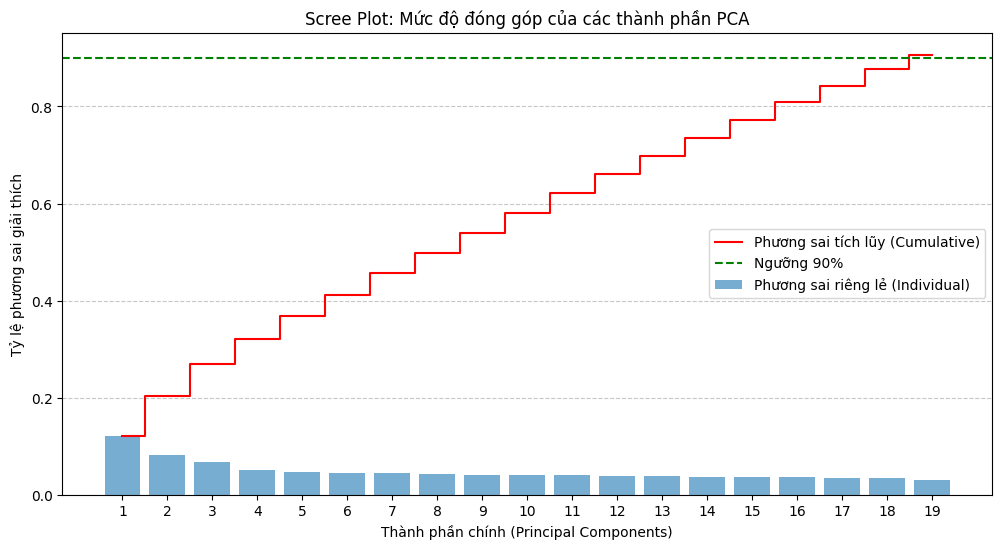

Tổng số thành phần cần thiết để giữ 90% phương sai: 19


In [297]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Khởi tạo PCA để giữ lại 90% phương sai dựa trên tập train 80/20
pca = PCA(n_components=0.90)
pca.fit(X_train_80_s)

# Lấy dữ liệu phương sai
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.6, align='center', label='Phương sai riêng lẻ (Individual)')
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid', color='red', label='Phương sai tích lũy (Cumulative)')

plt.axhline(y=0.90, color='green', linestyle='--', label='Ngưỡng 90%')
plt.ylabel('Tỷ lệ phương sai giải thích')
plt.xlabel('Thành phần chính (Principal Components)')
plt.title('Scree Plot: Mức độ đóng góp của các thành phần PCA')
plt.xticks(np.arange(1, len(exp_var_pca) + 1, 1))
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Tổng số thành phần cần thiết để giữ 90% phương sai: {len(exp_var_pca)}")

### 1. Phân tích tham số thống kê của dữ liệu
Trước khi giảm chiều, chúng ta cần xem xét các đặc tính thống kê cơ bản của dữ liệu đã chuẩn hóa.

In [298]:
import pandas as pd
import numpy as np

# Chuyển đổi mảng đã chuẩn hóa về DataFrame để dễ phân tích
X_train_df = pd.DataFrame(X_train_80_s, columns=X.columns)

# Thống kê mô tả (Mean, Std, Min, Max)
stats_summary = X_train_df.describe().T
display(stats_summary[['mean', 'std', 'min', 'max']].head(10))

,mean,std,min,max
BMI,5.216332e-16,1.000002,-2.530001,10.269608
Smoking,-4.715894e-17,1.000002,-0.853203,1.172053
AlcoholDrinking,3.938743e-17,1.000002,-0.277247,3.606895
Stroke,-6.311409e-17,1.000002,-0.204554,4.888682
PhysicalHealth,5.298757e-17,1.000002,-0.439058,3.239070
MentalHealth,-2.531628e-17,1.000002,-0.506526,3.180313
DiffWalking,-8.831262e-17,1.000002,-0.415844,2.404747
Sex,-2.143053e-17,1.000002,-0.944501,1.058760
AgeCategory,-8.230736e-17,1.000002,-1.816830,1.532528
PhysicalActivity,5.969933e-17,1.000002,-1.799826,0.555609


### 2. Thực hiện PCA và Đánh giá phương sai giải thích
Chúng ta sẽ xác định lượng thông tin được bảo toàn qua các thành phần chính.

In [299]:
from sklearn.decomposition import PCA

# Khởi tạo PCA giữ lại toàn bộ các thành phần để đánh giá
pca_full = PCA()
pca_full.fit(X_train_80_s)

# Tỷ lệ phương sai giải thích
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Hiển thị bảng thông số cho 6 thành phần đầu tiên
pca_stats = pd.DataFrame({
    'Thành phần chính': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Phương sai riêng lẻ': explained_variance,
    'Phương sai tích lũy': cumulative_variance
})
display(pca_stats.head(30))

,Thành phần chính,Phương sai riêng lẻ,Phương sai tích lũy
0,PC1,0.121234,0.121234
1,PC2,0.081200,0.202434
2,PC3,0.066551,0.268985
3,PC4,0.051323,0.320308
4,PC5,0.046971,0.367279
5,PC6,0.044596,0.411875
6,PC7,0.044116,0.455992
7,PC8,0.042556,0.498548
8,PC9,0.041492,0.540040
9,PC10,0.041406,0.581446


### 3. Trực quan hóa các cặp thành phần chính (PC1 đến PC6)
Sử dụng các biểu đồ Scatter Plot để quan sát sự phân bố dữ liệu.

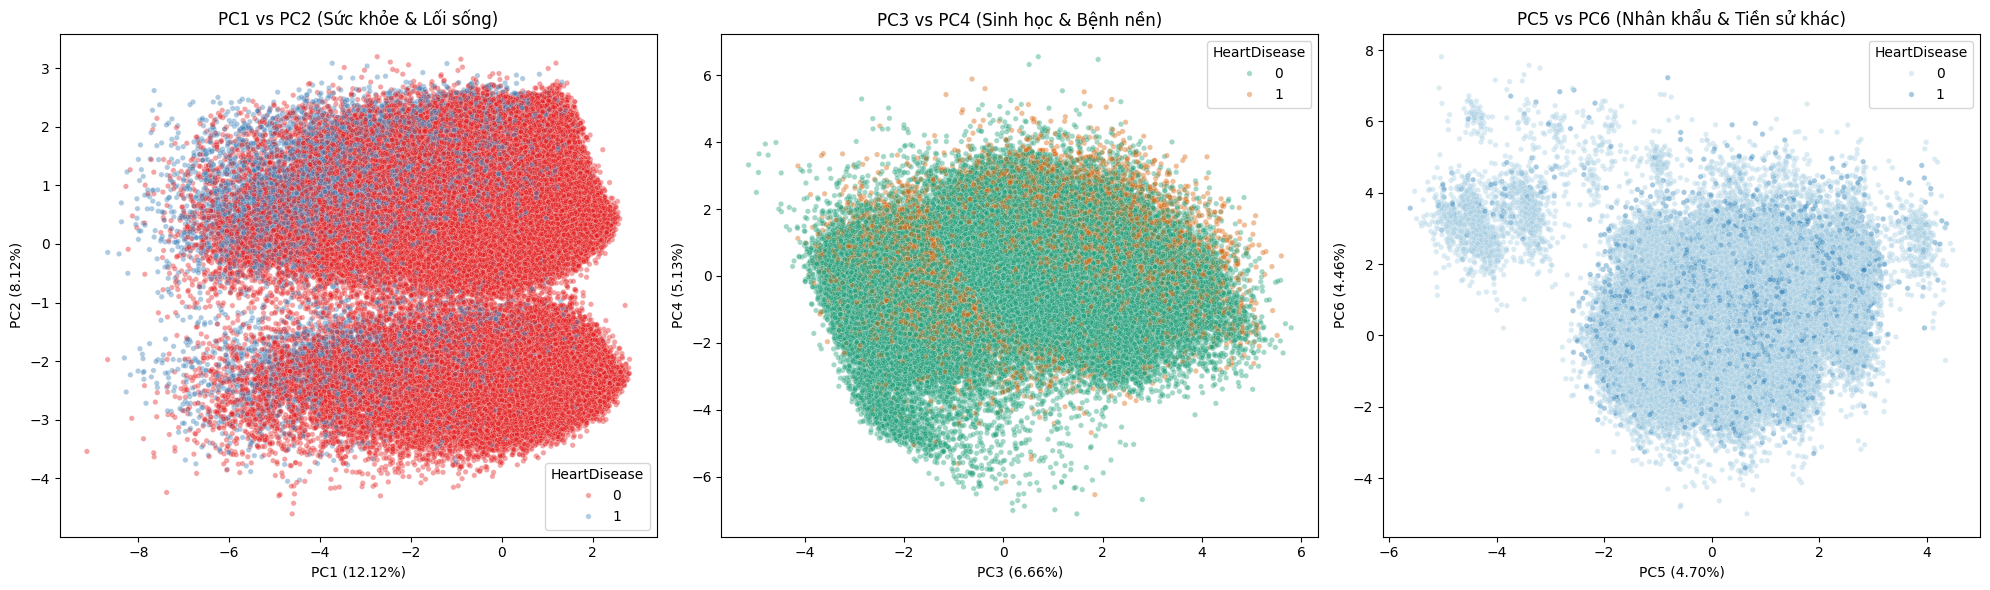

In [300]:
# Trực quan hóa lại các cặp thành phần chính từ PC1 đến PC6 với màu sắc rõ ràng hơn
import matplotlib.pyplot as plt
import seaborn as sns

# Đảm bảo X_pca đã được transform từ pca_full
X_pca_plot = pca_full.transform(X_train_80_s)

plt.figure(figsize=(20, 6))

# Cặp PC1 - PC2: Sức khỏe tổng quát, Vận động vs Lối sống
plt.subplot(1, 3, 1)
sns.scatterplot(x=X_pca_plot[:, 0], y=X_pca_plot[:, 1], hue=y_train_80, alpha=0.4, palette='Set1', s=15)
plt.title('PC1 vs PC2 (Sức khỏe & Lối sống)')
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%})')

# Cặp PC3 - PC4: Chỉ số sinh học & Bệnh nền (BMI, Tiểu đường...)
plt.subplot(1, 3, 2)
sns.scatterplot(x=X_pca_plot[:, 2], y=X_pca_plot[:, 3], hue=y_train_80, alpha=0.4, palette='Dark2', s=15)
plt.title('PC3 vs PC4 (Sinh học & Bệnh nền)')
plt.xlabel(f'PC3 ({pca_full.explained_variance_ratio_[2]:.2%})')
plt.ylabel(f'PC4 ({pca_full.explained_variance_ratio_[3]:.2%})')

# Cặp PC5 - PC6: Nhân khẩu học & Tiền sử bệnh khác
plt.subplot(1, 3, 3)
sns.scatterplot(x=X_pca_plot[:, 4], y=X_pca_plot[:, 5], hue=y_train_80, alpha=0.4, palette='Paired', s=15)
plt.title('PC5 vs PC6 (Nhân khẩu & Tiền sử khác)')
plt.xlabel(f'PC5 ({pca_full.explained_variance_ratio_[4]:.2%})')
plt.ylabel(f'PC6 ({pca_full.explained_variance_ratio_[5]:.2%})')

plt.tight_layout()
plt.show()

### 4. Phân tích tương quan giữa các thành phần chính và đầu ra
Biểu đồ Boxplot giúp nhận diện liệu các thành phần chính có khả năng phân tách được người mắc bệnh tim hay không.


C:\Users\Hoang Dung\AppData\Local\Temp\ipykernel_20100\1458018281.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y=f'PC{i+1}', data=pca_df, palette='Set2')
C:\Users\Hoang Dung\AppData\Local\Temp\ipykernel_20100\1458018281.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y=f'PC{i+1}', data=pca_df, palette='Set2')
C:\Users\Hoang Dung\AppData\Local\Temp\ipykernel_20100\1458018281.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y=f'PC{i+1}', data=pca_df, palette='Set2')
C:\Users\H

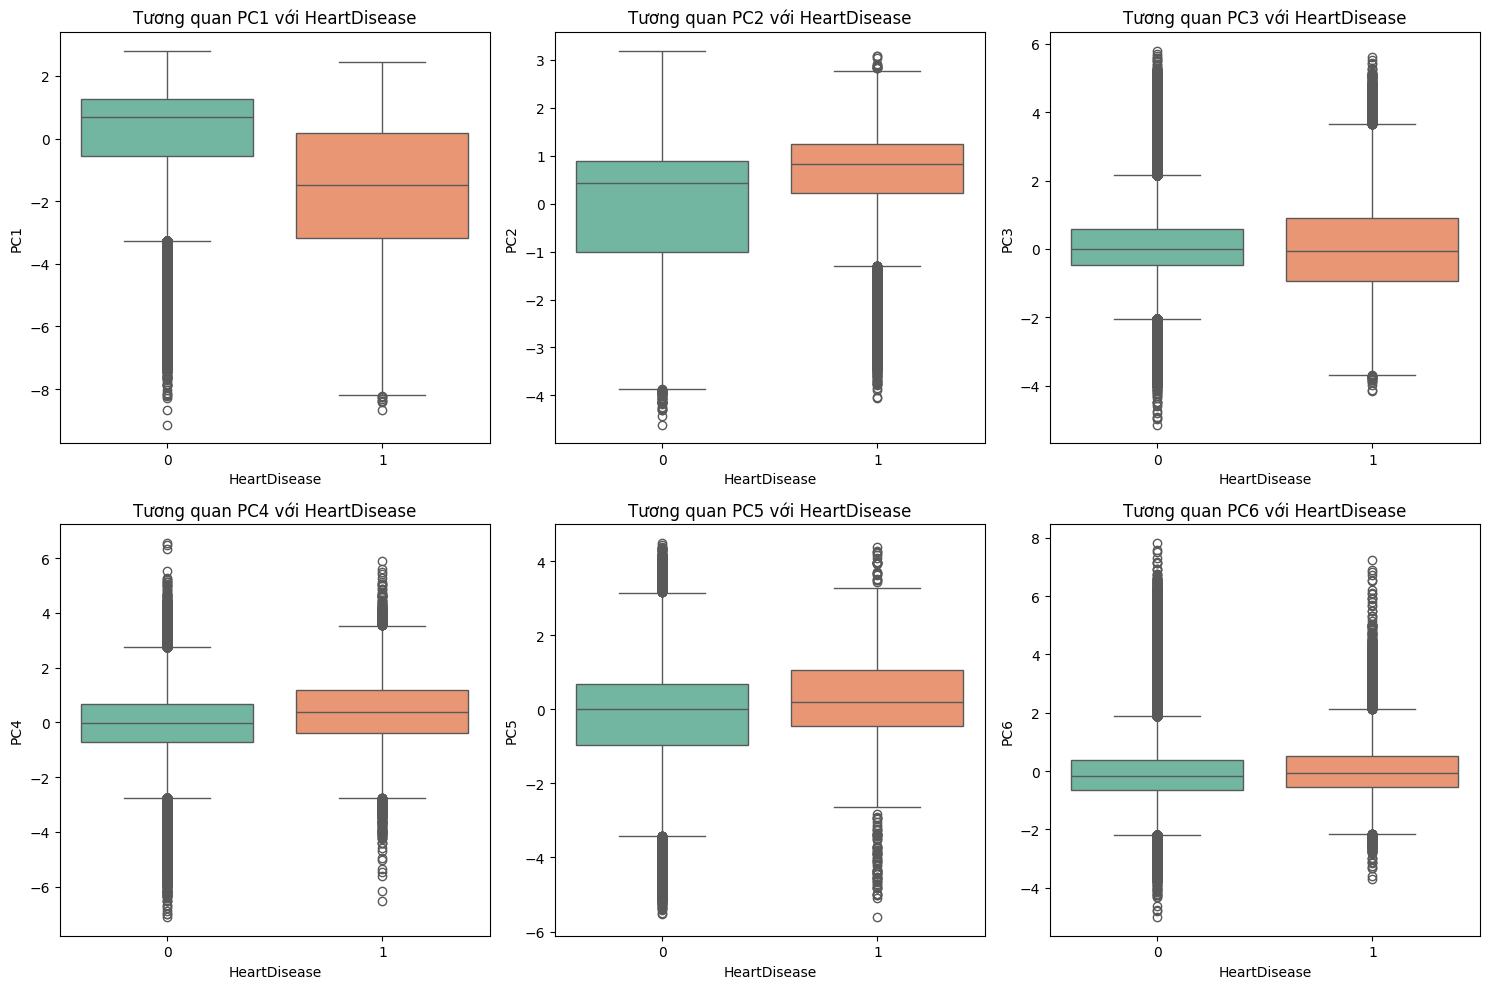

In [301]:
# Tạo DataFrame kết hợp giữa PCA và nhãn
pca_df = pd.DataFrame(X_pca_plot[:, :6], columns=[f'PC{i+1}' for i in range(6)])
pca_df['HeartDisease'] = y_train_80.values

plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='HeartDisease', y=f'PC{i+1}', data=pca_df, palette='Set2')
    plt.title(f'Tương quan PC{i+1} với HeartDisease')

plt.tight_layout()
plt.show()

### 5. So sánh và Đánh giá tổng thể
- **Thông tin bảo tồn:** Thành phần chính PC1 giải thích khoảng 12% phương sai, và cần tới 19 thành phần để giữ lại 90% thông tin. Điều này cho thấy dữ liệu có độ phức tạp cao và các biến có sự đóng góp khá đồng đều.
- **Cụm dữ liệu:** Qua biểu đồ Scatter Plot, các lớp (Bệnh tim/Không bệnh tim) chồng lấn lên nhau rất nhiều trong không gian PCA, cho thấy bài toán phân loại này không tuyến tính và khá thách thức.
- **Giảm chiều:** PCA giúp giảm từ 25 chiều xuống không gian ít hơn nhưng vẫn giữ được cấu trúc dữ liệu chính, hỗ trợ mô hình huấn luyện nhanh hơn.

## Phương pháp giảm chiều dữ liệu LDA

In [302]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)

# Fit trên train
X_train_lda = lda.fit_transform(X_train_80_s, y_train_80)

# Transform test
X_test_lda = lda.transform(X_test_20_s)

print("Shape sau LDA:", X_train_lda.shape)

Shape sau LDA: (241373, 1)


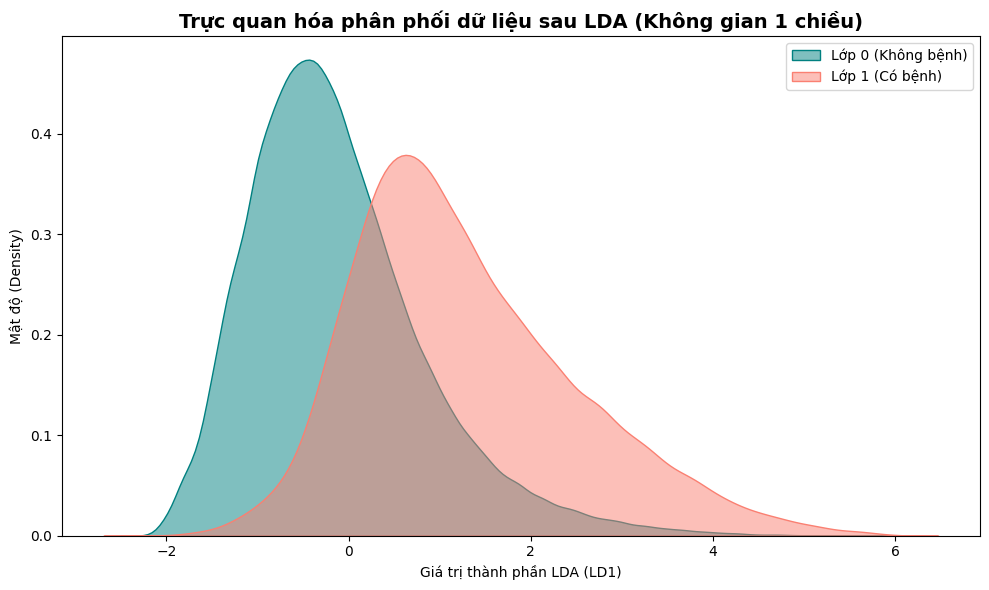

Tỷ lệ phương sai phân biệt được giải thích bởi LD1: 100.00%


In [303]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tách dữ liệu LDA theo từng nhãn (Lớp 0 và Lớp 1)
lda_class_0 = X_train_lda[y_train_80 == 0]
lda_class_1 = X_train_lda[y_train_80== 1]

# Khởi tạo kích thước khung hình
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ mật độ (KDE plot) cho từng lớp
# flatten() để chuyển ma trận (N, 1) thành mảng 1 chiều (N,) cho seaborn
sns.kdeplot(lda_class_0.flatten(), fill=True, color='teal', label='Lớp 0 (Không bệnh)', alpha=0.5)
sns.kdeplot(lda_class_1.flatten(), fill=True, color='salmon', label='Lớp 1 (Có bệnh)', alpha=0.5)

# Định dạng biểu đồ
plt.title('Trực quan hóa phân phối dữ liệu sau LDA (Không gian 1 chiều)', fontsize=14, fontweight='bold')
plt.xlabel('Giá trị thành phần LDA (LD1)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.tight_layout()
plt.show()

# Hiển thị tỷ lệ phương sai giải thích
print(f"Tỷ lệ phương sai phân biệt được giải thích bởi LD1: {lda.explained_variance_ratio_[0]*100:.2f}%")

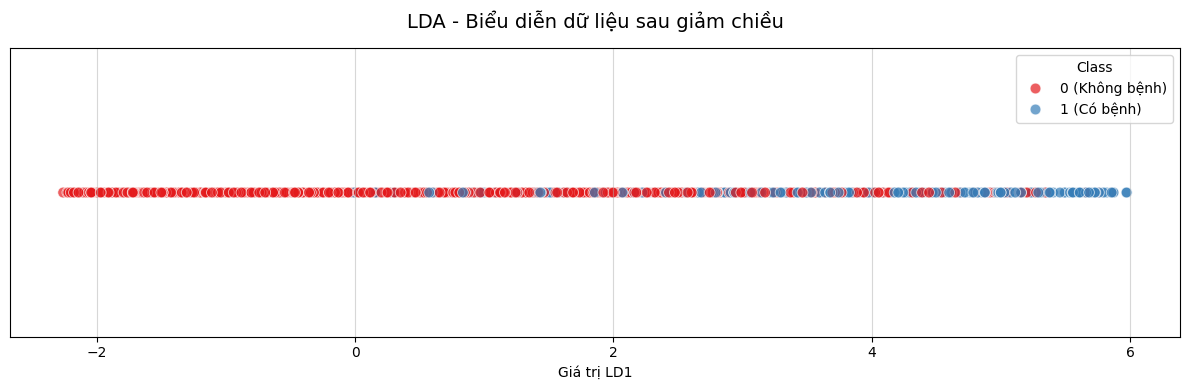

In [304]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 4)) # Điều chỉnh kích thước cho giống hình chữ nhật dài


y_zeros = np.zeros_like(X_train_lda.flatten())

# Sử dụng seaborn để vẽ, thiết lập màu đỏ cho lớp 0 và xanh cho lớp 1
sns.scatterplot(
    x=X_train_lda.flatten(), 
    y=y_zeros, 
    hue=y_train_80, 
    palette={0: '#e41a1c', 1: '#377eb8'}, # 
    s=60,             # Kích thước điểm
    alpha=0.7,          # Độ trong suốt (giúp nhìn rõ các điểm đè lên nhau)
    edgecolor='white'   # Viền trắng quanh các điểm
)

# Xóa các vạch chia và số trên trục Y vì chúng không có ý nghĩa trong biểu đồ 1D
plt.yticks([]) 
plt.ylabel('') # Bỏ tên trục Y

plt.title('LDA - Biểu diễn dữ liệu sau giảm chiều', fontsize=14, pad=15)
plt.xlabel('Giá trị LD1')

# Định dạng lại chú thích (Legend)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['0 (Không bệnh)', '1 (Có bệnh)'], title='Class', loc='upper right')

# Thêm lưới dọc để dễ gióng giá trị
plt.grid(axis='x', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

## Nhận xét và đánh giá kết quả phân tích LDA
Dựa trên kết quả trực quan hóa dữ liệu sau khi áp dụng kỹ thuật giảm chiều Linear Discriminant Analysis (LDA) vào bài toán dự đoán nguy cơ sức khỏe, chúng ta có các nhận xét cụ thể như sau:  

**1. Hiệu quả giảm chiều và phân tách tâm**
- **Chuyển đổi không gian:** Phương pháp LDA đã thực hiện nén các đặc trưng đầu vào thành một thành phần đơn nhất ($LD1$), giúp đơn giản hóa việc quan sát cấu trúc dữ liệu trên không gian 1 chiều mà vẫn giữ được thông tin quan trọng để phân biệt giữa các lớp.  
- **Sự tách biệt về vị trí trung bình:** Biểu đồ mật độ cho thấy giá trị trung bình (mean) của hai nhóm có sự khác biệt rõ rệt.Nhóm Lớp 0 (Không bệnh) tập trung chủ yếu quanh giá trị âm (đỉnh tại $\approx -0.5$).Nhóm Lớp 1 (Có bệnh) dịch chuyển về phía các giá trị dương (đỉnh tại $\approx 0.8$).  

**2. Phân tích vùng chồng lấn (Overlapping)**  
- **Mức độ giao thoa:** Mặc dù tâm của hai lớp tách rời, cả biểu đồ phân tán và biểu đồ mật độ đều ghi nhận một vùng chồng lấn đáng kể, tập trung mạnh nhất trong khoảng giá trị $LD1$ từ $0$ đến $2$.
- **Hệ quả đối với mô hình tuyến tính:**
 Sự hiện diện của vùng chồng lấn này cho thấy dữ liệu không thể phân tách tuyến tính hoàn toàn (linearly separable). Điều này đồng nghĩa với việc nếu chỉ sử dụng một ngưỡng (threshold) cố định trên trục $LD1$ để phân loại, mô hình sẽ gặp phải sai số nhất định (bao gồm cả False Positive và False Negative).  
 
**3. Đặc điểm phân phối của các lớp**
 - **Độ biến thiên:** Nhóm Lớp 1 (Có bệnh) có phân phối rộng hơn và lệch phải (right-skewed), kéo dài đến giá trị $6$ trên trục $LD1$. Điều này phản ánh sự biến động lớn trong các chỉ số sinh học của nhóm có bệnh so với nhóm bình thường.
 - **Mật độ tập trung:** Nhóm Lớp 0 có mật độ tập trung cao hơn và phân phối hẹp hơn, cho thấy tính đồng nhất tương đối của các đối tượng không có nguy cơ sức khỏe trong tập dữ liệu này.

## Kết luận và hướng phát triển
Kết luận: Kỹ thuật LDA đã tìm được hướng chiếu tối ưu nhất để phân tách dữ liệu theo phương pháp tuyến tính. Tuy nhiên, ranh giới giữa "Không bệnh" và "Có bệnh" có sự giao thoa tự nhiên, phản ánh độ phức tạp thực tế của bài toán dự đoán sức khỏe.

## Mô hình GaussianNB

In [305]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model(X_train, X_test, y_train, y_test, title):
    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n===== {title} =====")

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # Precision, Recall, F1
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC - {title}")
    plt.legend()
    plt.show()

    return acc, auc, y_pred, y_prob

## Dữ liệu gốc


===== 80/20 - Raw =====
Accuracy: 0.8033441601484821
              precision    recall  f1-score   support

           0       0.95      0.83      0.88     54892
           1       0.24      0.55      0.34      5452

    accuracy                           0.80     60344
   macro avg       0.60      0.69      0.61     60344
weighted avg       0.88      0.80      0.83     60344



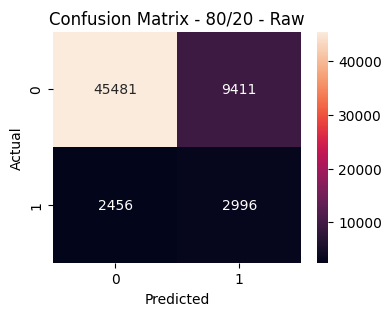

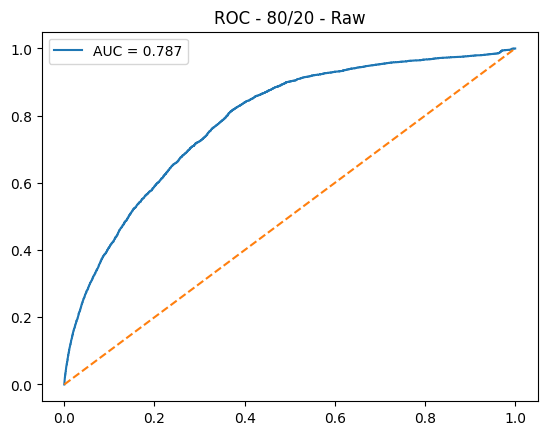


===== 70/30 - Raw =====
Accuracy: 0.8042445534491139
              precision    recall  f1-score   support

           0       0.95      0.83      0.89     82338
           1       0.24      0.55      0.34      8178

    accuracy                           0.80     90516
   macro avg       0.60      0.69      0.61     90516
weighted avg       0.89      0.80      0.84     90516



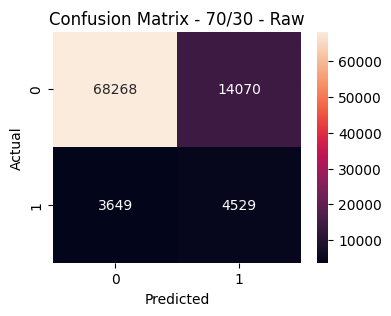

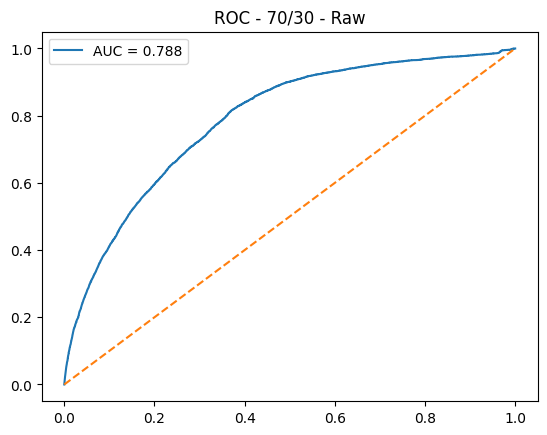


===== 60/40 - Raw =====
Accuracy: 0.8046517023374514
              precision    recall  f1-score   support

           0       0.95      0.83      0.89    109783
           1       0.24      0.56      0.34     10904

    accuracy                           0.80    120687
   macro avg       0.60      0.69      0.61    120687
weighted avg       0.89      0.80      0.84    120687



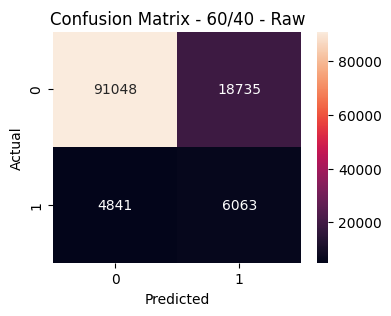

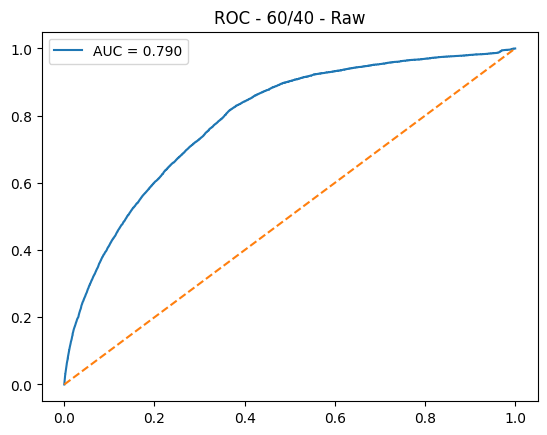

In [306]:
res_raw_80 = evaluate_model(X_train_80_s, X_test_20_s, y_train_80, y_test_20, "80/20 - Raw")
res_raw_70 = evaluate_model(X_train_70_s, X_test_30_s, y_train_70, y_test_30, "70/30 - Raw")
res_raw_60 = evaluate_model(X_train_60_s, X_test_40_s, y_train_60, y_test_40, "60/40 - Raw")

## Trên dữ liệu đã giảm chiều LDA


===== 80/20 - LDA =====
Accuracy: 0.9041495426222989
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     54892
           1       0.44      0.22      0.29      5452

    accuracy                           0.90     60344
   macro avg       0.68      0.60      0.62     60344
weighted avg       0.88      0.90      0.89     60344



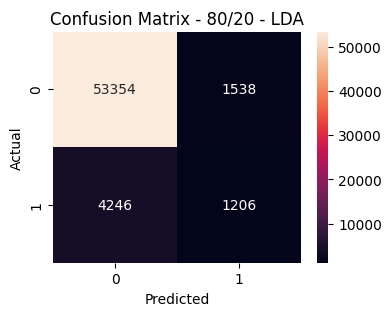

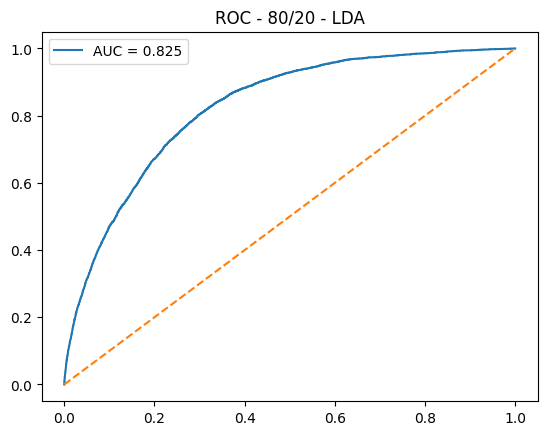


===== 70/30 - LDA =====
Accuracy: 0.9033761986831057
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     82338
           1       0.43      0.22      0.29      8178

    accuracy                           0.90     90516
   macro avg       0.68      0.60      0.62     90516
weighted avg       0.88      0.90      0.89     90516



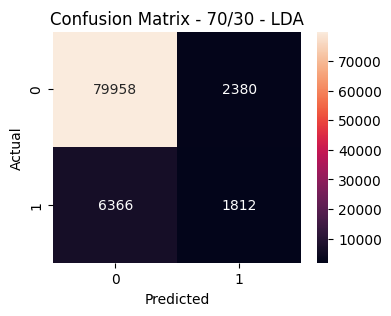

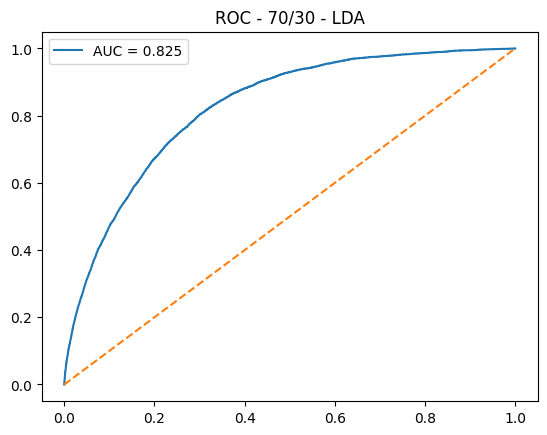


===== 60/40 - LDA =====
Accuracy: 0.902955579308459
              precision    recall  f1-score   support

           0       0.93      0.97      0.95    109783
           1       0.43      0.22      0.29     10904

    accuracy                           0.90    120687
   macro avg       0.68      0.60      0.62    120687
weighted avg       0.88      0.90      0.89    120687



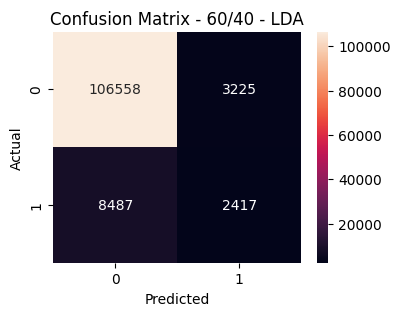

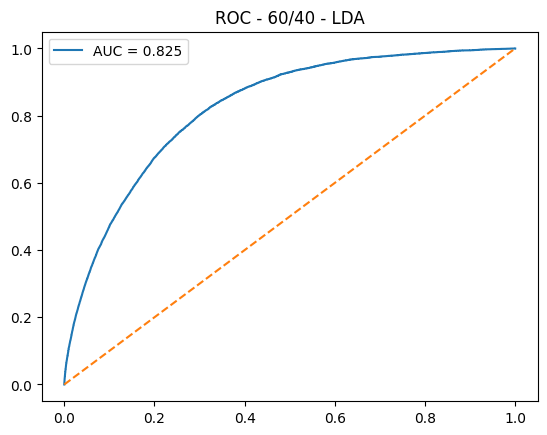

In [307]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def apply_lda(X_train, X_test, y_train):
    lda = LinearDiscriminantAnalysis(n_components=1)
    X_train_lda = lda.fit_transform(X_train, y_train)
    X_test_lda = lda.transform(X_test)
    return X_train_lda, X_test_lda

# Apply
X_train_80_lda, X_test_20_lda = apply_lda(X_train_80_s, X_test_20_s, y_train_80)
X_train_70_lda, X_test_30_lda = apply_lda(X_train_70_s, X_test_30_s, y_train_70)
X_train_60_lda, X_test_40_lda = apply_lda(X_train_60_s, X_test_40_s, y_train_60)

# Evaluate
res_lda_80 = evaluate_model(X_train_80_lda, X_test_20_lda, y_train_80, y_test_20, "80/20 - LDA")
res_lda_70 = evaluate_model(X_train_70_lda, X_test_30_lda, y_train_70, y_test_30, "70/30 - LDA")
res_lda_60 = evaluate_model(X_train_60_lda, X_test_40_lda, y_train_60, y_test_40, "60/40 - LDA")

## GaussianNB với dữ liệu giảm chiều PCA

In [308]:
from sklearn.decomposition import PCA

def apply_pca(X_train, X_test):
    pca = PCA(n_components=0.90)  # giữ 90% thông tin
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)
    return X_train_pca, X_test_pca


===== 80/20 - PCA =====
Accuracy: 0.850556807636219
              precision    recall  f1-score   support

           0       0.93      0.90      0.92     54892
           1       0.26      0.36      0.31      5452

    accuracy                           0.85     60344
   macro avg       0.60      0.63      0.61     60344
weighted avg       0.87      0.85      0.86     60344



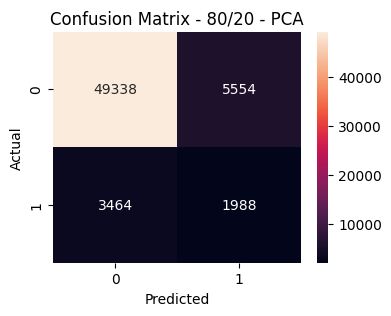

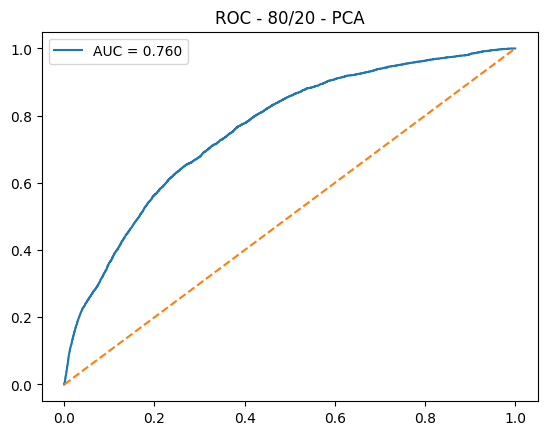


===== 70/30 - PCA =====
Accuracy: 0.8500265146493438
              precision    recall  f1-score   support

           0       0.93      0.90      0.92     82338
           1       0.26      0.37      0.31      8178

    accuracy                           0.85     90516
   macro avg       0.60      0.63      0.61     90516
weighted avg       0.87      0.85      0.86     90516



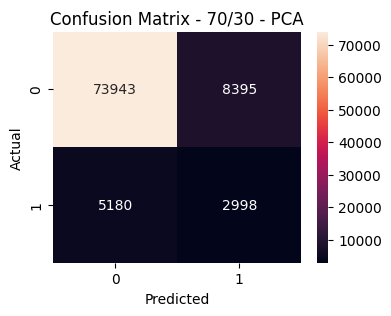

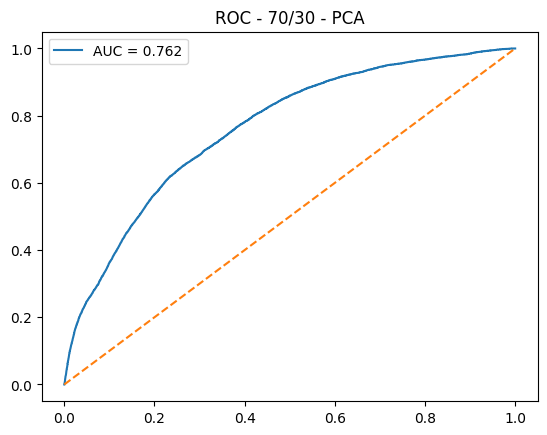


===== 60/40 - PCA =====
Accuracy: 0.8536462087880219
              precision    recall  f1-score   support

           0       0.93      0.90      0.92    109783
           1       0.27      0.36      0.31     10904

    accuracy                           0.85    120687
   macro avg       0.60      0.63      0.61    120687
weighted avg       0.87      0.85      0.86    120687



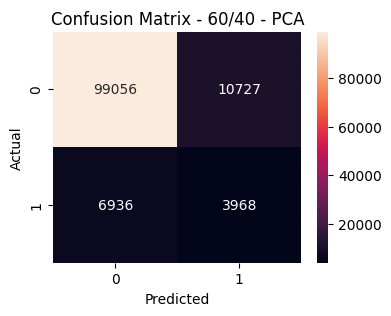

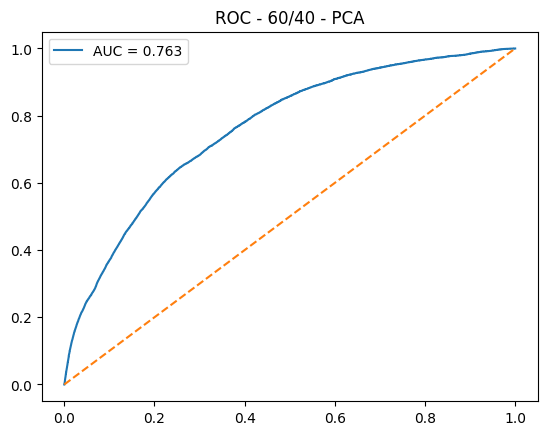

In [309]:
# 80/20
X_train_80_pca, X_test_20_pca = apply_pca(X_train_80_s, X_test_20_s)
pca_80 = evaluate_model(X_train_80_pca, X_test_20_pca, y_train_80, y_test_20, "80/20 - PCA")

# 70/30
X_train_70_pca, X_test_30_pca = apply_pca(X_train_70_s, X_test_30_s)
pca_70 = evaluate_model(X_train_70_pca, X_test_30_pca, y_train_70, y_test_30, "70/30 - PCA")

# 60/40
X_train_60_pca, X_test_40_pca = apply_pca(X_train_60_s, X_test_40_s)
pca_60 = evaluate_model(X_train_60_pca, X_test_40_pca, y_train_60, y_test_40, "60/40 - PCA")

## Trực quan Residual(Sai lệch)

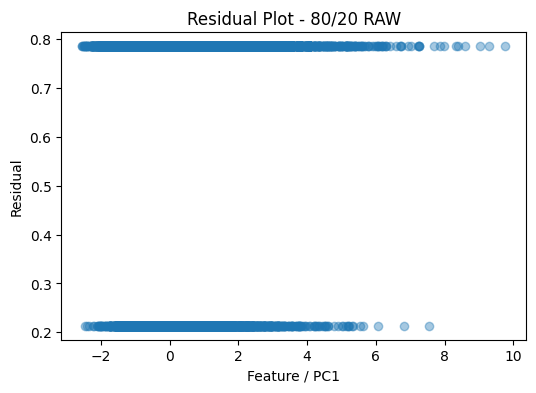

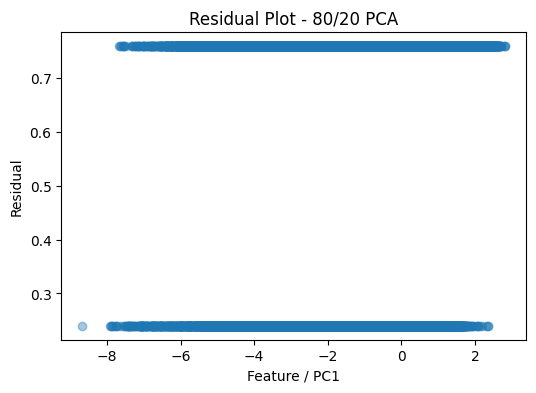

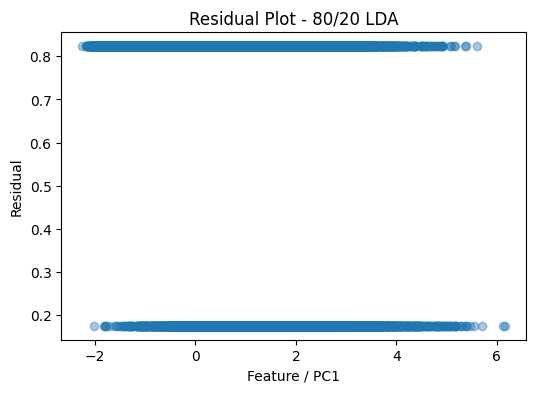

In [310]:
def plot_residuals(X_test, y_test, y_pred, title):
    residuals = np.abs(y_pred - y_test)

    plt.figure(figsize=(6,4))
    plt.scatter(X_test[:,0], residuals, alpha=0.4)
    plt.xlabel("Feature / PC1")
    plt.ylabel("Residual")
    plt.title(f"Residual Plot - {title}")
    plt.show()

# Ví dụ PCA 80/20
plot_residuals(X_test_20_s,y_test_20, res_raw_80[1],"80/20 RAW")
plot_residuals(X_test_20_pca, y_test_20, pca_80[1], "80/20 PCA")
plot_residuals(X_test_20_lda,y_test_20,res_lda_80[1],"80/20 LDA")

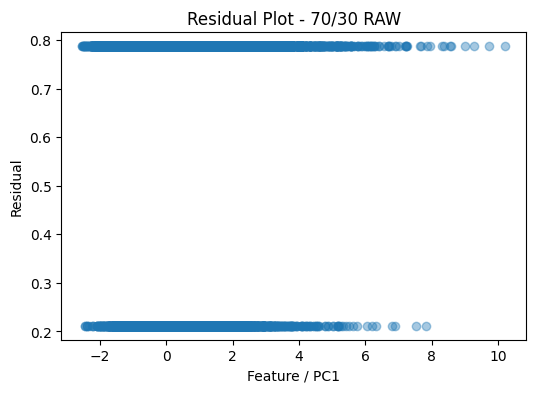

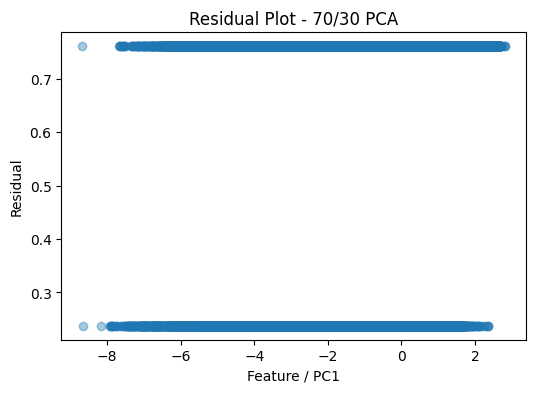

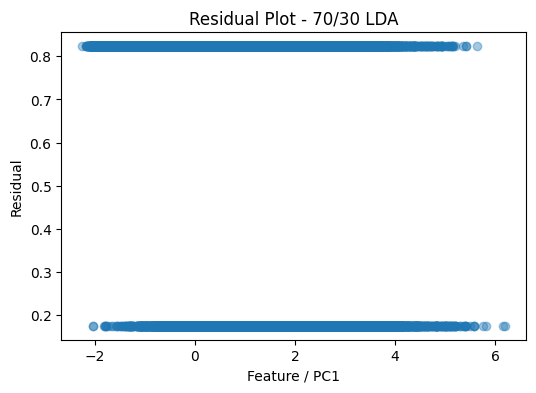

In [311]:
plot_residuals(X_test_30_s,y_test_30, res_raw_70[1],"70/30 RAW")
plot_residuals(X_test_30_pca, y_test_30, pca_70[1], "70/30 PCA")
plot_residuals(X_test_30_lda,y_test_30,res_lda_70[1],"70/30 LDA")

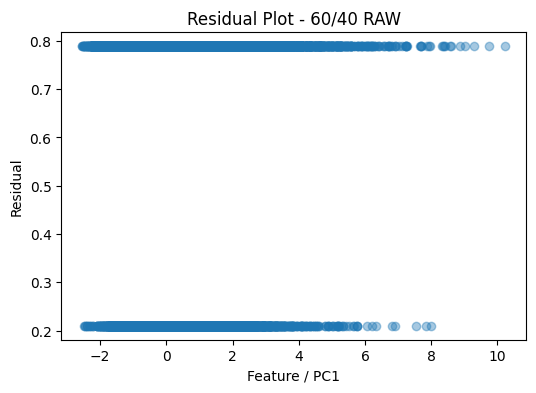

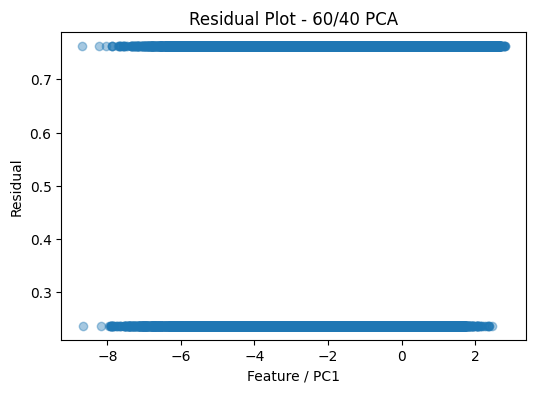

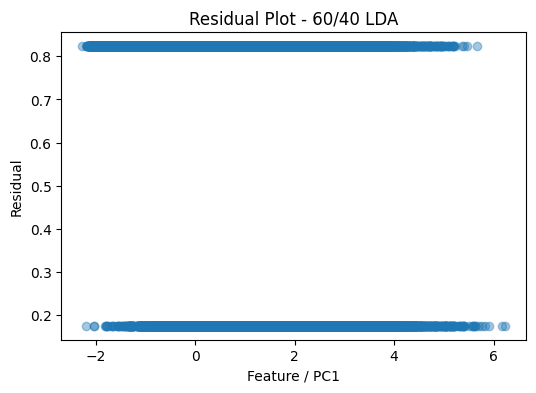

In [312]:
plot_residuals(X_test_40_s,y_test_40, res_raw_60[1],"60/40 RAW")
plot_residuals(X_test_40_pca, y_test_40, pca_60[1], "60/40 PCA")
plot_residuals(X_test_40_lda,y_test_40,res_lda_60[1],"60/40 LDA")

In [313]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(y_test, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Yes)": precision_score(y_test, y_pred),
        "Recall (Yes)": recall_score(y_test, y_pred),
        "F1-score (Yes)": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

In [314]:
results = []

def append_metrics_from_result(name, result, y_test):
    _, _, y_pred, y_prob = result
    metrics = get_metrics(y_test, y_pred, y_prob)
    metrics["Scenario"] = name
    results.append(metrics)


def append_metrics_from_model(name, X_train, X_test, y_train, y_test):
    model = GaussianNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = get_metrics(y_test, y_pred, y_prob)
    metrics["Scenario"] = name
    results.append(metrics)

# ===== RAW =====
append_metrics_from_result("Original - 80/20", res_raw_80, y_test_20)
append_metrics_from_result("Original - 70/30", res_raw_70, y_test_30)
append_metrics_from_result("Original - 60/40", res_raw_60, y_test_40)

# ===== PCA =====
append_metrics_from_model("PCA - 80/20", X_train_80_pca, X_test_20_pca, y_train_80, y_test_20)
append_metrics_from_model("PCA - 70/30", X_train_70_pca, X_test_30_pca, y_train_70, y_test_30)
append_metrics_from_model("PCA - 60/40", X_train_60_pca, X_test_40_pca, y_train_60, y_test_40)

# ===== LDA =====
append_metrics_from_result("LDA - 80/20", res_lda_80, y_test_20)
append_metrics_from_result("LDA - 70/30", res_lda_70, y_test_30)
append_metrics_from_result("LDA - 60/40", res_lda_60, y_test_40)

# Tạo DataFrame
df_results = pd.DataFrame(results)

# Sắp xếp cột đẹp
df_results = df_results[
    ["Scenario", "Accuracy", "Precision (Yes)", "Recall (Yes)", "F1-score (Yes)", "AUC"]
]

# Làm tròn
df_results = df_results.round(4)

# Hiển thị
display(df_results)

,Scenario,Accuracy,Precision (Yes),Recall (Yes),F1-score (Yes),AUC
0,Original - 80/20,0.8033,0.2415,0.5495,0.3355,0.7865
1,Original - 70/30,0.8042,0.2435,0.5538,0.3383,0.7882
2,Original - 60/40,0.8047,0.2445,0.5560,0.3396,0.7900
3,PCA - 80/20,0.8506,0.2636,0.3646,0.3060,0.7600
4,PCA - 70/30,0.8500,0.2631,0.3666,0.3064,0.7624
5,PCA - 60/40,0.8536,0.2700,0.3639,0.3100,0.7631
6,LDA - 80/20,0.9041,0.4395,0.2212,0.2943,0.8246
7,LDA - 70/30,0.9034,0.4323,0.2216,0.2930,0.8246
8,LDA - 60/40,0.9030,0.4284,0.2217,0.2922,0.8247


##  Hồi quy Logistic trên tất cả các tập dữ liệu
 thực hiện huấn luyện mô hình Logistic Regression (Binary) cho từng tỉ lệ phân chia đã thực hiện ở bước trước.

In [315]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_logistic(X_train, X_test, y_train, y_test, title):
    model = LogisticRegression(
        class_weight = 'balanced',
        max_iter=1000,
        C=1.0,              # regularization strength
        penalty='l2',       # L2 regularization
        solver='lbfgs'
        
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n===== {title} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC - {title}")
    plt.legend()
    plt.show()

    return model, y_pred, y_prob, auc


===== 80/20 - RAW =====
Accuracy: 0.7429239029563834
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     54892
           1       0.23      0.77      0.35      5452

    accuracy                           0.74     60344
   macro avg       0.60      0.76      0.60     60344
weighted avg       0.90      0.74      0.80     60344



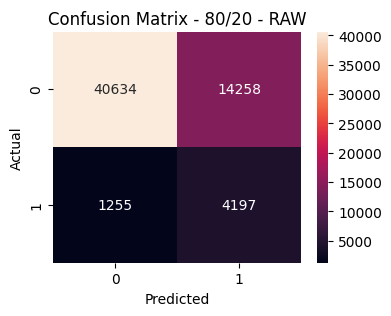

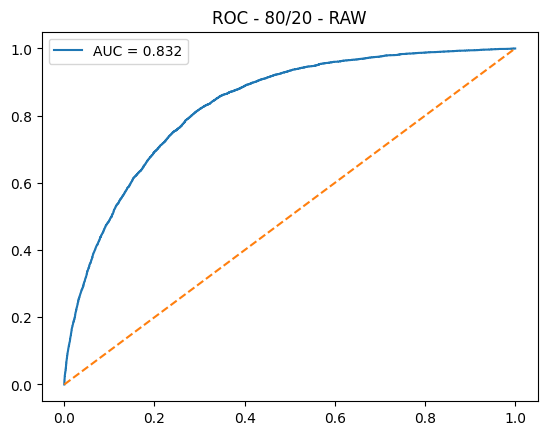


===== 70/30 - RAW =====
Accuracy: 0.7427416147421451
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     82338
           1       0.23      0.77      0.35      8178

    accuracy                           0.74     90516
   macro avg       0.60      0.75      0.60     90516
weighted avg       0.90      0.74      0.80     90516



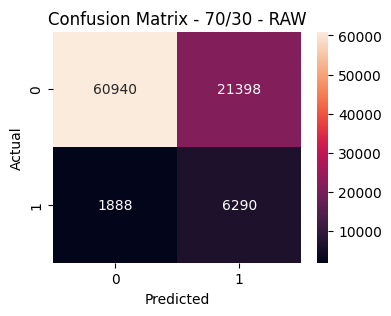

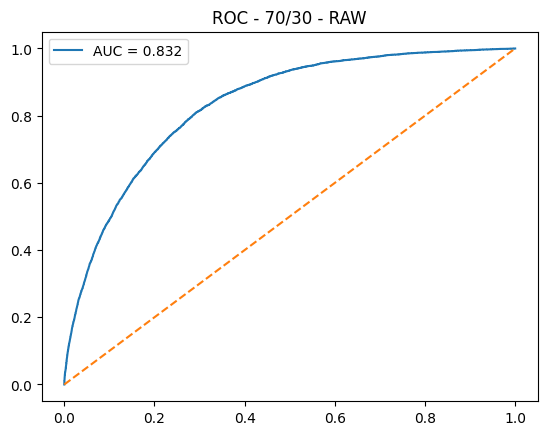


===== 60/40 - RAW =====
Accuracy: 0.7427560549189225
              precision    recall  f1-score   support

           0       0.97      0.74      0.84    109783
           1       0.23      0.77      0.35     10904

    accuracy                           0.74    120687
   macro avg       0.60      0.75      0.60    120687
weighted avg       0.90      0.74      0.80    120687



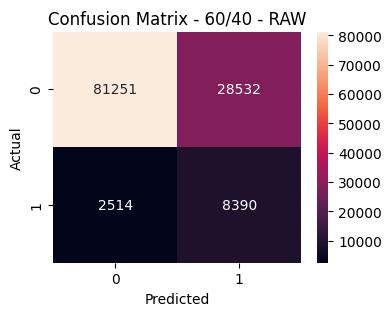

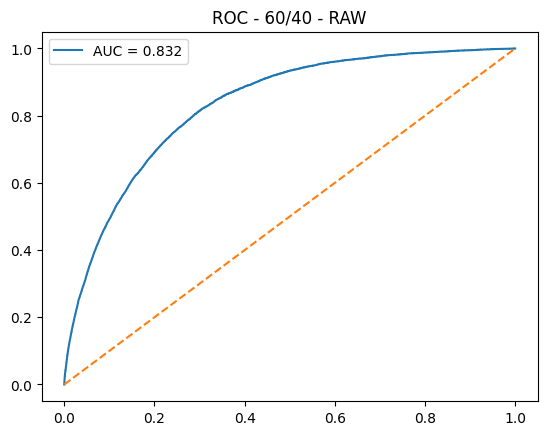

In [316]:
log_raw_80 = evaluate_logistic(X_train_80_s, X_test_20_s, y_train_80, y_test_20, "80/20 - RAW")
log_raw_70 = evaluate_logistic(X_train_70_s, X_test_30_s, y_train_70, y_test_30, "70/30 - RAW")
log_raw_60 = evaluate_logistic(X_train_60_s, X_test_40_s, y_train_60, y_test_40, "60/40 - RAW")

## Thực hiện trên dữ liệu giảm chiều PCA


===== 80/20 - PCA =====
Accuracy: 0.7566949489593
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     54892
           1       0.23      0.71      0.34      5452

    accuracy                           0.76     60344
   macro avg       0.60      0.73      0.60     60344
weighted avg       0.90      0.76      0.80     60344



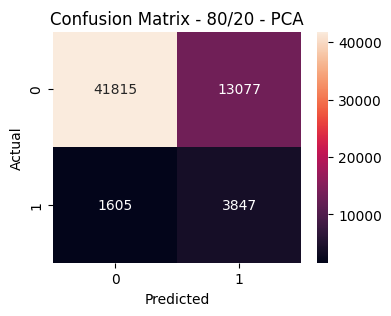

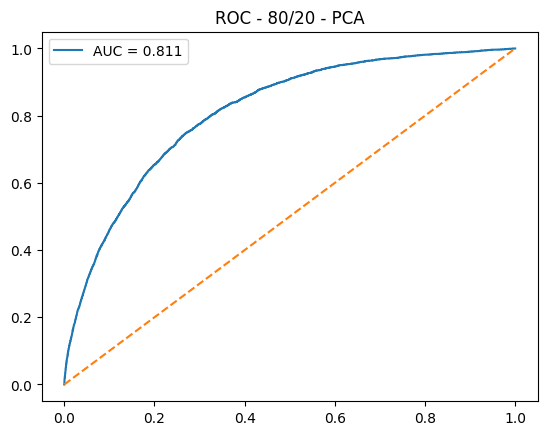


===== 70/30 - PCA =====
Accuracy: 0.7563635158425029
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     82338
           1       0.23      0.70      0.34      8178

    accuracy                           0.76     90516
   macro avg       0.59      0.73      0.60     90516
weighted avg       0.90      0.76      0.80     90516



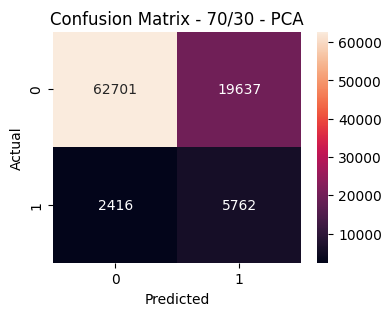

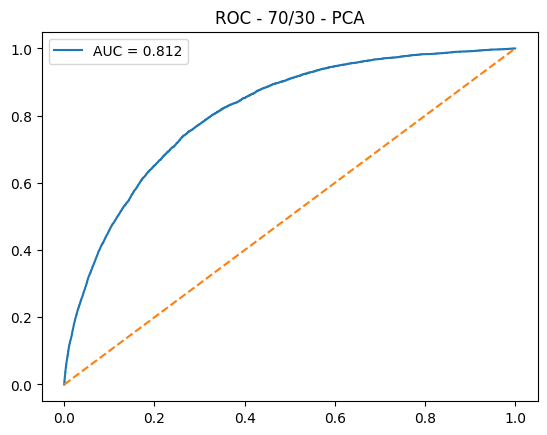


===== 60/40 - PCA =====
Accuracy: 0.7551848997820809
              precision    recall  f1-score   support

           0       0.96      0.76      0.85    109783
           1       0.23      0.70      0.34     10904

    accuracy                           0.76    120687
   macro avg       0.59      0.73      0.60    120687
weighted avg       0.90      0.76      0.80    120687



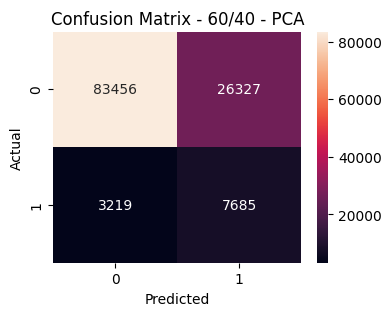

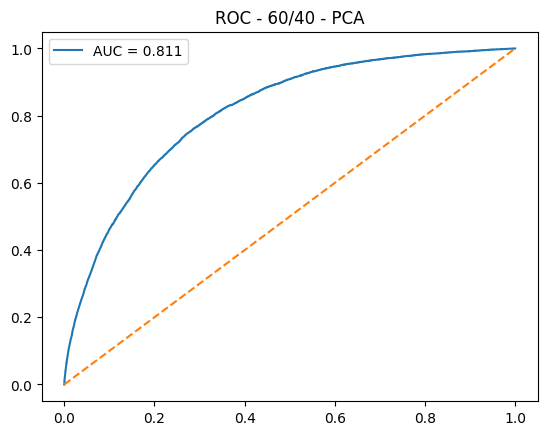

In [317]:

from sklearn.decomposition import PCA

def apply_pca(X_train, X_test):
    pca = PCA(n_components=0.90)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)
    return X_train_pca, X_test_pca

# Apply
X_train_80_pca, X_test_20_pca = apply_pca(X_train_80_s, X_test_20_s)
X_train_70_pca, X_test_30_pca = apply_pca(X_train_70_s, X_test_30_s)
X_train_60_pca, X_test_40_pca = apply_pca(X_train_60_s, X_test_40_s)

# Evaluate
log_pca_80 = evaluate_logistic(X_train_80_pca, X_test_20_pca, y_train_80, y_test_20, "80/20 - PCA")
log_pca_70 = evaluate_logistic(X_train_70_pca, X_test_30_pca, y_train_70, y_test_30, "70/30 - PCA")
log_pca_60 = evaluate_logistic(X_train_60_pca, X_test_40_pca, y_train_60, y_test_40, "60/40 - PCA")

## Thực hiện trên dữ liệu giảm chiều LDA


===== 80/20 - LDA =====
Accuracy: 0.7731506032082726
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     54892
           1       0.24      0.70      0.36      5452

    accuracy                           0.77     60344
   macro avg       0.60      0.74      0.61     60344
weighted avg       0.90      0.77      0.82     60344



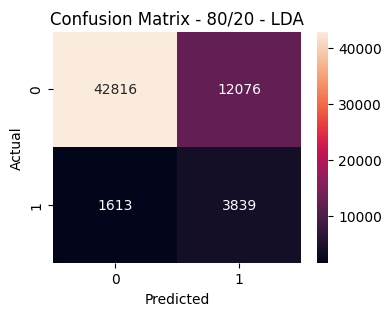

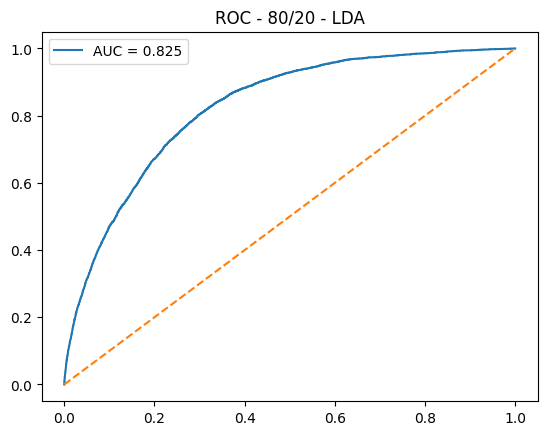


===== 70/30 - LDA =====
Accuracy: 0.7721949710548411
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     82338
           1       0.24      0.71      0.36      8178

    accuracy                           0.77     90516
   macro avg       0.60      0.74      0.61     90516
weighted avg       0.90      0.77      0.82     90516



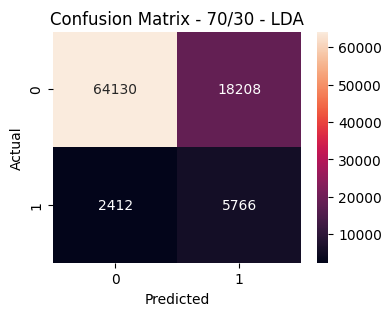

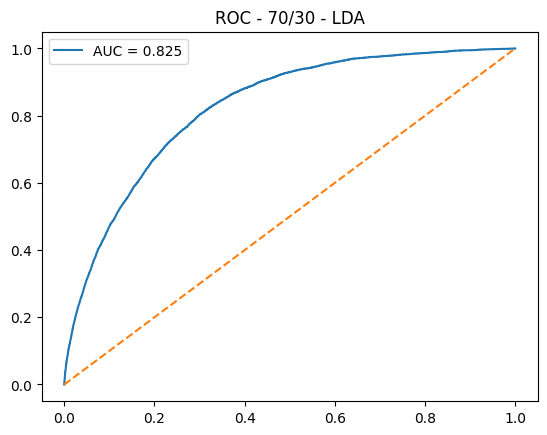


===== 60/40 - LDA =====
Accuracy: 0.7716406903809027
              precision    recall  f1-score   support

           0       0.96      0.78      0.86    109783
           1       0.24      0.71      0.36     10904

    accuracy                           0.77    120687
   macro avg       0.60      0.74      0.61    120687
weighted avg       0.90      0.77      0.82    120687



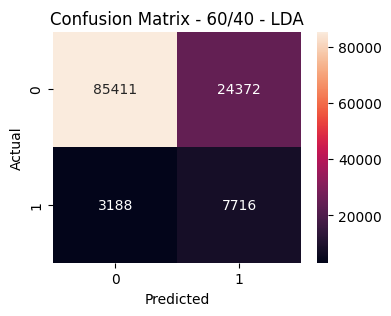

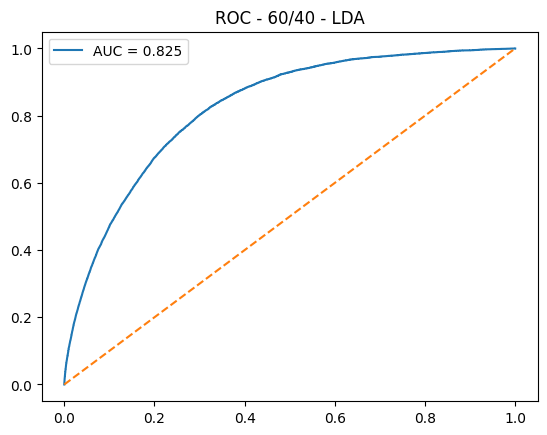

In [318]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def apply_lda(X_train, X_test, y_train):
    lda = LinearDiscriminantAnalysis(n_components=1)
    X_train_lda = lda.fit_transform(X_train, y_train)
    X_test_lda  = lda.transform(X_test)
    return X_train_lda, X_test_lda

# Apply
X_train_80_lda, X_test_20_lda = apply_lda(X_train_80_s, X_test_20_s, y_train_80)
X_train_70_lda, X_test_30_lda = apply_lda(X_train_70_s, X_test_30_s, y_train_70)
X_train_60_lda, X_test_40_lda = apply_lda(X_train_60_s, X_test_40_s, y_train_60)

# Evaluate
log_lda_80 = evaluate_logistic(X_train_80_lda, X_test_20_lda, y_train_80, y_test_20, "80/20 - LDA")
log_lda_70 = evaluate_logistic(X_train_70_lda, X_test_30_lda, y_train_70, y_test_30, "70/30 - LDA")
log_lda_60 = evaluate_logistic(X_train_60_lda, X_test_40_lda, y_train_60, y_test_40, "60/40 - LDA")

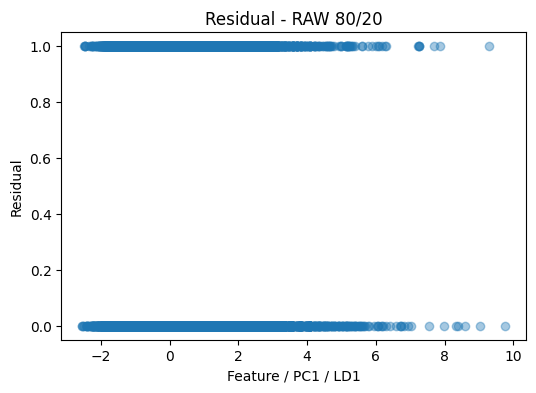

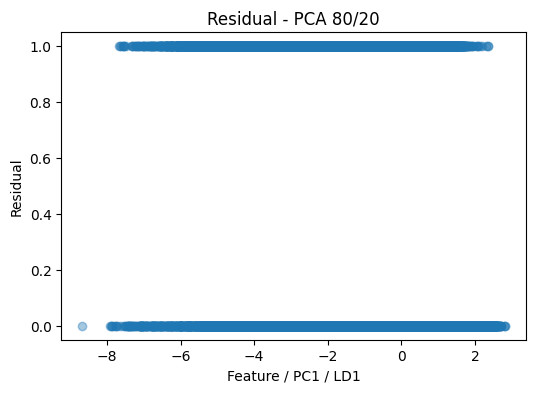

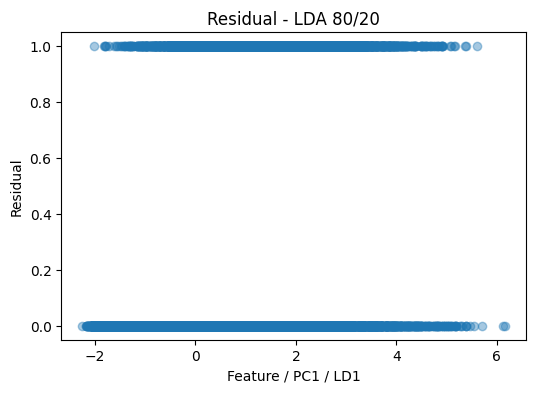

In [319]:
def plot_residuals(X_test, y_test, y_pred, title):
    residuals = np.abs(y_pred - y_test)

    plt.figure(figsize=(6,4))
    plt.scatter(X_test[:,0], residuals, alpha=0.4)
    plt.xlabel("Feature / PC1 / LD1")
    plt.ylabel("Residual")
    plt.title(f"Residual - {title}")
    plt.show()

plot_residuals(X_test_20_s, y_test_20, log_raw_80[1], "RAW 80/20")
plot_residuals(X_test_20_pca, y_test_20, log_pca_80[1], "PCA 80/20")
plot_residuals(X_test_20_lda, y_test_20, log_lda_80[1], "LDA 80/20")

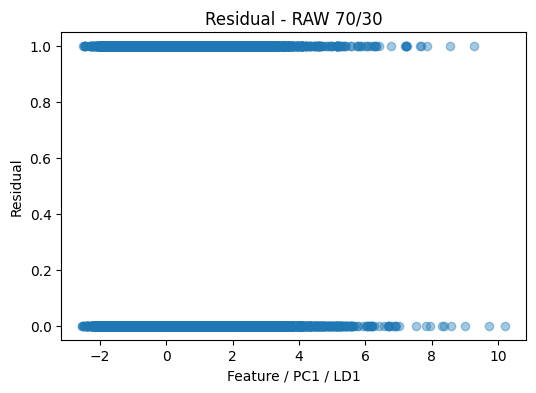

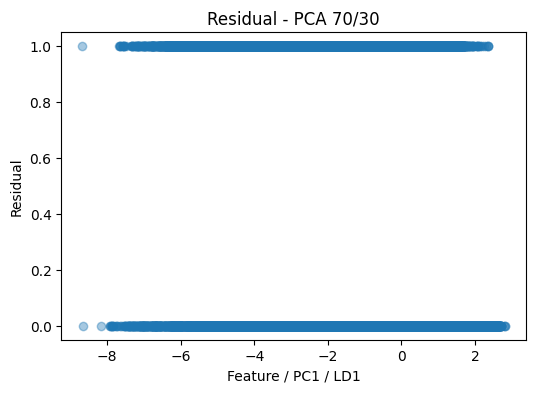

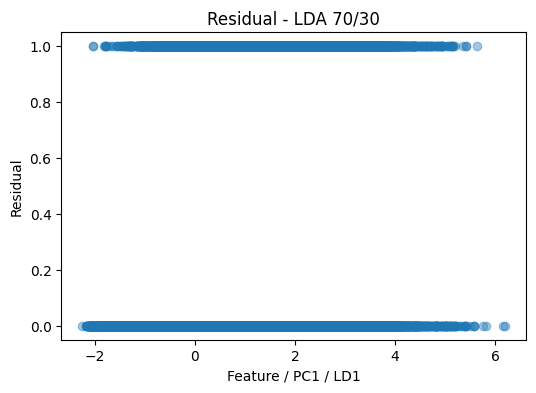

In [320]:
plot_residuals(X_test_30_s, y_test_30, log_raw_70[1], "RAW 70/30")
plot_residuals(X_test_30_pca, y_test_30, log_pca_70[1], "PCA 70/30")
plot_residuals(X_test_30_lda, y_test_30, log_lda_70[1], "LDA 70/30")

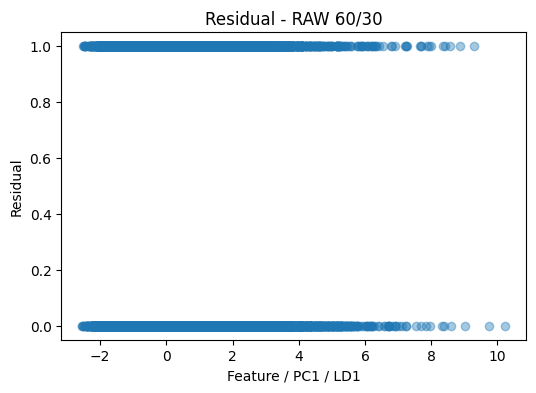

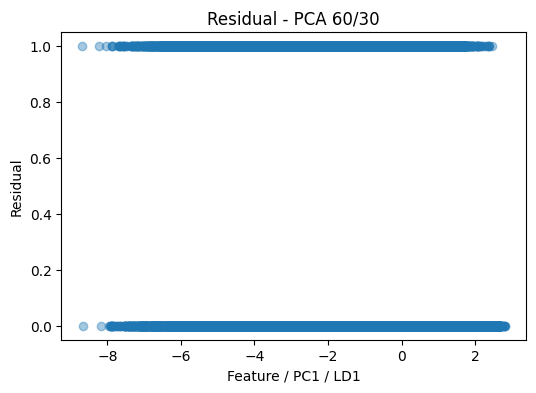

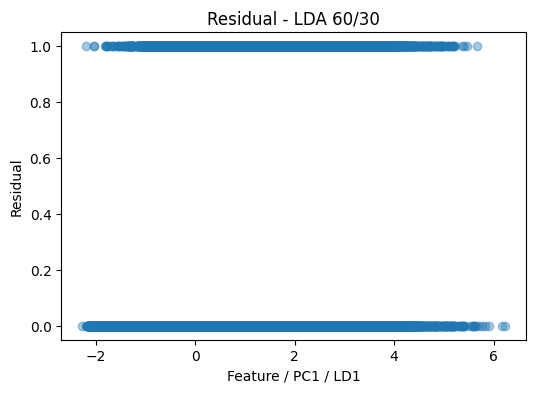

In [321]:
plot_residuals(X_test_40_s, y_test_40, log_raw_60[1], "RAW 60/30")
plot_residuals(X_test_40_pca, y_test_40, log_pca_60[1], "PCA 60/30")
plot_residuals(X_test_40_lda, y_test_40, log_lda_60[1], "LDA 60/30")

### 7. Nhận xét về ROC Curve và AUC

**Chỉ số AUC:** Giá trị AUC khoảng **0.82** (hoặc tương tự) cho thấy mô hình có khả năng phân biệt tương đối tốt giữa lớp 'Yes' (có bệnh tim) và 'No' (không bệnh tim). Một mô hình hoàn hảo sẽ có AUC = 1, trong khi một mô hình dự đoán ngẫu nhiên sẽ có AUC = 0.5.

**Đường cong ROC:** Đường cong nằm khá xa đường chéo (random classifier), điều này khẳng định khả năng phân loại của mô hình tốt hơn đáng kể so với việc đoán ngẫu nhiên. Tuy nhiên, nó vẫn chưa đạt đến mức lý tưởng (tiệm cận góc trên bên trái của biểu đồ), cho thấy vẫn còn những giới hạn trong việc phân tách hoàn hảo hai lớp.

**Ý nghĩa:** AUC = 0.82 là một kết quả chấp nhận được đối với một mô hình Logistic Regression trên tập dữ liệu mất cân bằng như vậy. Nó xác nhận rằng mô hình có giá trị trong việc phân loại, mặc dù các chỉ số Precision/Recall cho lớp thiểu số vẫn còn thấp. Điều này thường xảy ra khi chúng ta ưu tiên Recall cho lớp thiểu số (như đã làm với `class_weight='balanced'`), dẫn đến việc chấp nhận một lượng False Positives cao hơn để không bỏ sót các trường hợp Positive thực sự.

In [322]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(y_test, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Yes)": precision_score(y_test, y_pred),
        "Recall (Yes)": recall_score(y_test, y_pred),
        "F1-score (Yes)": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

In [323]:
results = []

# ===== RAW =====
for name, res, y_test in [
    ("RAW - 80/20", log_raw_80, y_test_20),
    ("RAW - 70/30", log_raw_70, y_test_30),
    ("RAW - 60/40", log_raw_60, y_test_40),
]:
    metrics = get_metrics(y_test, res[1], res[2])
    metrics["Scenario"] = name
    results.append(metrics)

# ===== PCA =====
for name, res, y_test in [
    ("PCA - 80/20", log_pca_80, y_test_20),
    ("PCA - 70/30", log_pca_70, y_test_30),
    ("PCA - 60/40", log_pca_60, y_test_40),
]:
    metrics = get_metrics(y_test, res[1], res[2])
    metrics["Scenario"] = name
    results.append(metrics)

# ===== LDA =====
for name, res, y_test in [
    ("LDA - 80/20", log_lda_80, y_test_20),
    ("LDA - 70/30", log_lda_70, y_test_30),
    ("LDA - 60/40", log_lda_60, y_test_40),
]:
    metrics = get_metrics(y_test, res[1], res[2])
    metrics["Scenario"] = name
    results.append(metrics)

# Tạo DataFrame
df_logistic = pd.DataFrame(results)

# Sắp xếp cột
df_logistic = df_logistic[
    ["Scenario", "Accuracy", "Precision (Yes)", "Recall (Yes)", "F1-score (Yes)", "AUC"]
]

# Làm tròn
df_logistic = df_logistic.round(4)

# Hiển thị
display(df_logistic)

,Scenario,Accuracy,Precision (Yes),Recall (Yes),F1-score (Yes),AUC
0,RAW - 80/20,0.7429,0.2274,0.7698,0.3511,0.8324
1,RAW - 70/30,0.7427,0.2272,0.7691,0.3508,0.8324
2,RAW - 60/40,0.7428,0.2272,0.7694,0.3509,0.8321
3,PCA - 80/20,0.7567,0.2273,0.7056,0.3439,0.8114
4,PCA - 70/30,0.7564,0.2269,0.7046,0.3432,0.8116
5,PCA - 60/40,0.7552,0.2259,0.7048,0.3422,0.8109
6,LDA - 80/20,0.7732,0.2412,0.7041,0.3593,0.8246
7,LDA - 70/30,0.7722,0.2405,0.7051,0.3587,0.8246
8,LDA - 60/40,0.7716,0.2405,0.7076,0.3590,0.8247
